In [34]:
using Distributions
using StatsFuns
using CairoMakie
using JLD2
using EM
filepath = ".."
include("../code/util.jl")

invunitnorm (generic function with 1 method)

# Beta Bernoulli Model

We're going to present an alternate learning mechanism to the HMM, a Beta Bernoulli learner

## Model Details
The value at port $i$ is represented by two variables, $\alpha_i$ and $\beta_i$, which respectively count the number of successes and failures at each port.

The mean is then given by $\mu_i = \frac{\alpha_i + 1}{\alpha_i + \beta_i + 2}$, where the offsets of 1 and 2 correspond to a distribution of $Beta(1,1)$ at baseline.

This baseline $Beta(1,1)$ is a uniform distribution over $[0,1]$ and has a mean of $\mu=0.5$



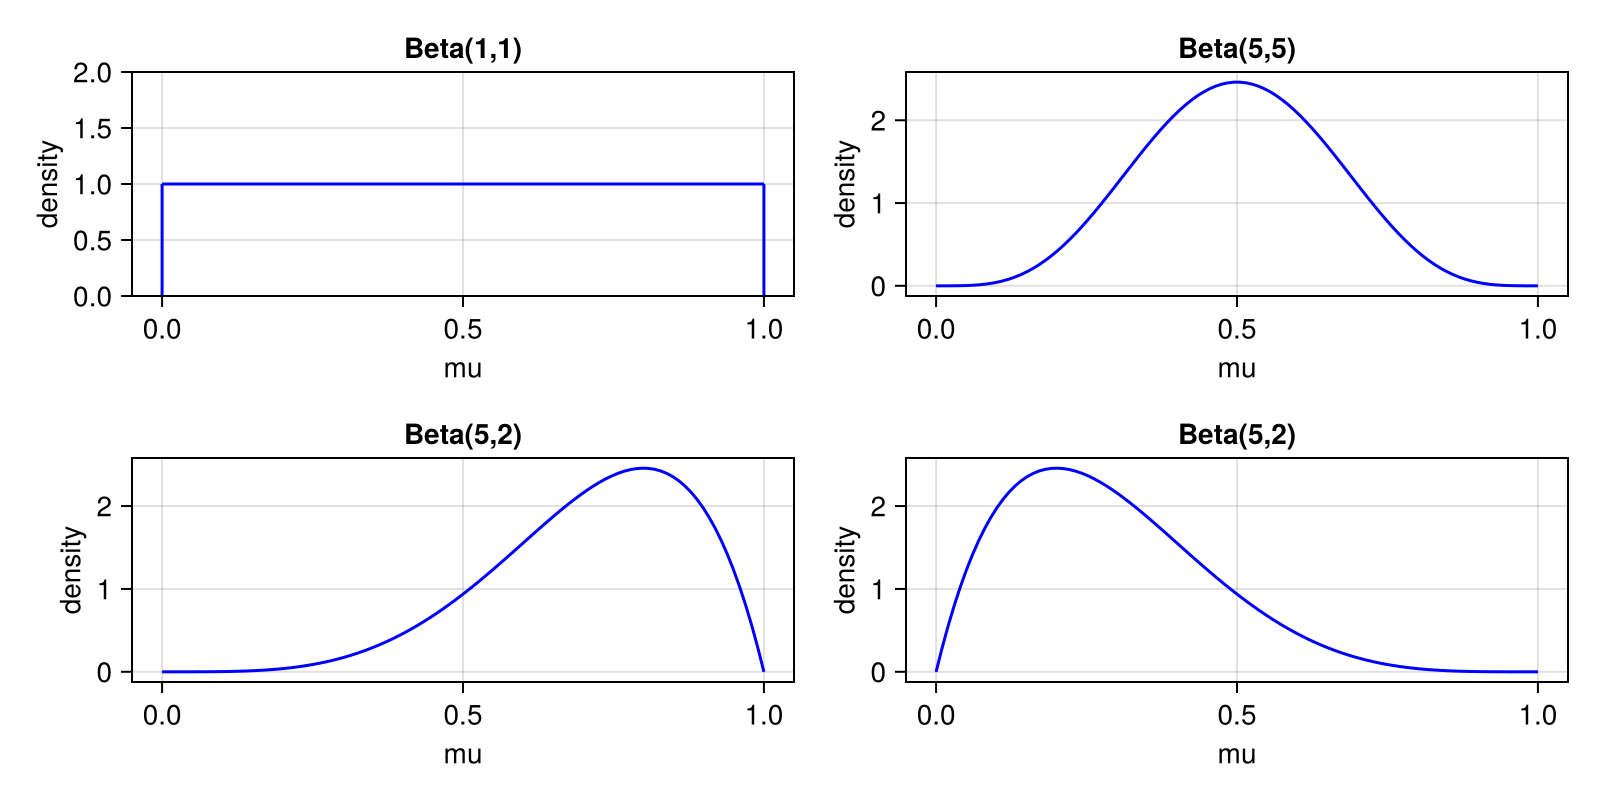

In [35]:
x = range(0, 1, length=100)

f = Figure(size = (800, 400))
ax = Axis(f[1, 1], xlabel = "mu", ylabel = "density", title="Beta(1,1)")
b11 = pdf(Beta(1,1), x)
lines!(ax, x, b11, color = :blue)
vlines!(ax, [0.0], color = :blue, ymin=0.0, ymax=0.5)
vlines!(ax, [1.0], color = :blue, ymin=0.0, ymax=0.5)
ax = Axis(f[1, 2], xlabel = "mu", ylabel = "density", title="Beta(5,5)")
b55 = pdf(Beta(5,5), x)
lines!(ax, x, b55, color = :blue)
ax = Axis(f[2, 1], xlabel = "mu", ylabel = "density", title="Beta(5,2)")
b52 = pdf(Beta(5,2), x)
lines!(ax, x, b52, color = :blue)
ax = Axis(f[2, 2], xlabel = "mu", ylabel = "density", title="Beta(5,2)")
b25 = pdf(Beta(2,5), x)
lines!(ax, x, b25, color = :blue)
f

After each trial, updating is performed as:
- $\alpha_i \leftarrow \alpha_i + r$
- $\beta_i \leftarrow \beta_i + (1 - r)$

This model gives us an easy estimation of variance / uncertainty - variance of the true mean is given by $\frac{(\alpha + 1)(\beta + 1)}{(\alpha + \beta + 2)^2(\alpha + \beta + 3)}$

### Decay
We can also introduce decay - over time, we allow the values of $\alpha$ and $\beta$ to relax back to 0, via:
- $\alpha_i \leftarrow (1-decay) * \alpha_i$
- $\beta_i \leftarrow (1-decay) * \beta_i$

This will approach $Beta(1,1)$

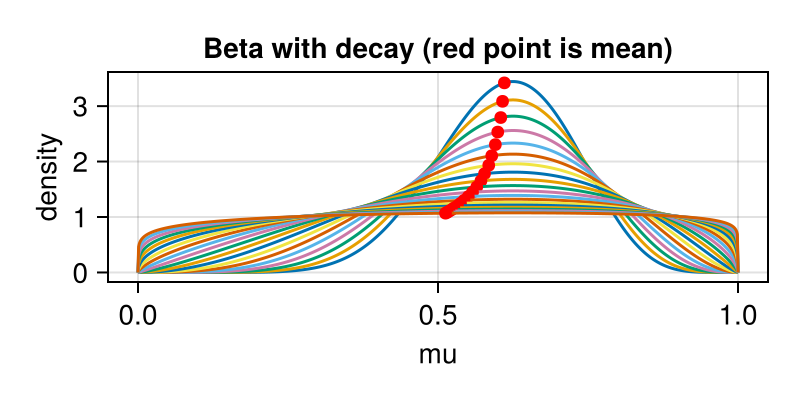

In [36]:
x = range(0, 1, length=1000)
a = 10
b = 6
decay = 0.2
f = Figure(size = (400, 200))
ax = Axis(f[1, 1], xlabel = "mu", ylabel = "density", title="Beta with decay (red point is mean)")
for i in 1:20
    p = pdf(Beta(a+1,b+1), x)
    lines!(ax, x, p)
    # Plot mean of dist
    m = (a+1)/(a+b+2)
    # Find closest point to m in X
    ind = Int(round(m * 1000))
    scatter!(ax, x[ind], p[ind], color = :red)
    a = a * (1 - decay)
    b = b * (1 - decay)
end
f

## Alternative Formulations

Note that the beta bernoulli model can be directly framed in terms of $\mu$ and $\sigma^2$. We can derive update rules for both of them rather than $\alpha$ and $\beta$, but these rules are somewhat more complicated and so are not used below.

# Likelihood

In [37]:
function em_opt_extended(trials,subs,X,betas,sigma,lik_fn,varnames;
    emtol=1e-3, maxiter=100, full=true, extended=true, quiet=false, threads=true, nstarts=1, noprior=false, startx=nothing)
    if noprior
        if nstarts > 1
            return emnoprior(trials,subs,X,betas,sigma,lik_fn;nstarts=nstarts)
        else
            return emnoprior(trials,subs,X,betas,sigma,lik_fn;nstarts=1)
        end
    else
        _startx = []
        if nstarts > 1
            _startx = eminits(trials,subs,X,betas,sigma,lik_fn;nstarts=nstarts,threads=threads)
        elseif !isnothing(startx)
            _startx = startx
        end
        (betas,sigma,x,l,h,opt_rec) = em(trials,subs,X,betas,sigma,lik_fn; emtol=emtol, full=full, maxiter=maxiter, quiet=quiet, threads=threads, startx=_startx);
        if extended
            try
                @info "Running emerrors"
                (standarderrors,pvalues,covmtx) = emerrors(trials,subs,x,X,h,betas,sigma,lik_fn)
                return EMResultsExtended(varnames,betas,sigma,x,l,h,opt_rec,standarderrors,pvalues,covmtx)
            catch err
                if isa(err, SingularException) || isa(err, DomainError) || isa(err, LAPACKException)
                @warn err
                    @warn "emerrors failed to run. Re-check fitting. Returning EMResults"
                    return EMResults(varnames,betas,sigma,x,l,h,opt_rec)
                else
                    rethrow()
                end
            end
        else
            return EMResults(varnames,betas,sigma,x,l,h,opt_rec)
        end
    end
end

function beta_mu(α, β)
    return α / (α + β)
end

function beta_var(α, β)
    return α * β / ((α + β)^2 * (α + β + 1))
end

function beta_lik(data, βgo, βstay::V, βleaf, stay_bias::W, turn_bias, spatial_bias, leaf_turn_bias, leaf_spatial_bias, beta_decay, γ2, retain_belief, delay_turn_bias::Bool, rewscaled::Bool, add_leaf::Bool, record::Bool) where {V, W}
    U = promote_type(eltype(βstay), eltype(stay_bias))  # this is a bit of a hack so that we can optionally have either of these fixed at 0
    # mode = "likelihood"

    # rename the variables for easy acccess
    r = data.reward
    c1 = data.stemchoice
    c2 = data.leafchoice

    # initialize 
    lik = 0.
    lik_go = 0.
    lik_stay = 0.
    lp_stay = 0.
    lp_turn = 0.
    lp_go = 0.
    prevs::Int = 0 #stem
    prevl::Int = 0 #leaf
    stem_stay_p = zeros(U, length(c1))
    stem_turn_alone_p = zeros(U, length(c1))
    stem_go_turn_p = zeros(U, length(c1))
    stem_1_p = zeros(U, length(c1))
    stem_2_p = zeros(U, length(c1))
    stem_3_p = zeros(U, length(c1))
    leaf_1_p = zeros(U, length(c1))
    leaf_2_p = zeros(U, length(c1))

    # Beta dist variables
    betadist_α = zeros(U, 3, 2, length(c1)+1)
    betadist_β = zeros(U, 3, 2, length(c1)+1)
    betadist_α[:, :, 1] .= 1.0
    betadist_β[:, :, 1] .= 1.0

    # Q-values
    # Choice-level representation
    Q = zeros(U,3,2,length(c1)+1)
    Qstem = zeros(U,3,length(c1))
    Qleaf = zeros(U,2,length(c1))
    Q[:, :, 1] .= betadist_α[:, :, 1] ./ (betadist_α[:, :, 1] + betadist_β[:, :, 1])
    if rewscaled
        @views Q[:, :, 1] .-= 0.5
    end

    for i in eachindex(c1)
        if ((i>1) && (data.daysessionnum[i] != data.daysessionnum[i-1]))
            betadist_α[:, :, 1] .= 1.0
            betadist_β[:, :, 1] .= 1.0
            @views Q[:, :, i] .= betadist_α[:, :, i] ./ (betadist_α[:, :, i] + betadist_β[:, :, i])
            if rewscaled
                @views Q[:, :, i] .-= 0.5
            end
            prevs = 0
            prevl = 0
        end

        # this is the (scaled) value of switching to each alternative stem
        # mean averages over both leaves
        # 
        # Seems to be faster breaking it up into the three calculations
        @views Qstem[1, i] = mean(Q[1, :, i]) * βgo
        @views Qstem[2, i] = mean(Q[2, :, i]) * βgo
        @views Qstem[3, i] = mean(Q[3, :, i]) * βgo

        if prevs > 0
            # this is the (scaled) value of staying with the current stem
            # uses only the value of the next leaf
            # plus the bias toward staying
            Qstem[prevs, i] = βstay * ((1.0 - γ2) * Q[prevs,3-prevl,i] + γ2 * Q[prevs,prevl,i]) + stay_bias
            # @views Qstem[:, i] .*= βgo
            # spatial bias
            # 1 -> 2, 2->3, 3->1
            # Probability of stay/switch
            # mod1(prevs + 1, 3) and mod1(prevs + 2, 3) give us the other two stems
            # log(exp(Q_x) / sum(exp.(Q))) -> Q_x - logsumexp(Q)
            if delay_turn_bias  # Compute stay/go before we add a turn bias
                @views lp_stay = Qstem[prevs, i] - logsumexp(Qstem[:, i])
                @views lp_go = logsumexp(Qstem[[mod1(prevs + 1, 3), mod1(prevs + 2, 3)], i]) - logsumexp(Qstem[:, i])
                Qstem[mod1(prevs + 1, 3), i] += spatial_bias[prevs] + turn_bias
            else # Or after we add the turn bias
                Qstem[mod1(prevs + 1, 3), i] += spatial_bias[prevs] + turn_bias
                @views lp_stay = Qstem[prevs, i] - logsumexp(Qstem[:, i])
                @views lp_go = logsumexp(Qstem[[mod1(prevs + 1, 3), mod1(prevs + 2, 3)], i]) - logsumexp(Qstem[:, i])
            end
            if prevs == c1[i]  # If a stay trial, just the stay/go likelihood
                ll = lp_stay
            else  # If a go trial, p(go) times the left/right turn choice
                @views lp_turn = Qstem[c1[i], i] - logsumexp(Qstem[[mod1(prevs + 1, 3), mod1(prevs + 2, 3)], i])
                ll = lp_go + lp_turn
            end
            stem_stay_p[i] = exp(lp_stay)
            stem_turn_alone_p[i] = exp(lp_turn)
            stem_go_turn_p[i] = exp(lp_go + lp_turn)

            @views stem_1_p[i] = exp(Qstem[1, i] - logsumexp(Qstem[:, i]))
            @views stem_2_p[i] = exp(Qstem[2, i] - logsumexp(Qstem[:, i]))
            @views stem_3_p[i] = exp(Qstem[3, i] - logsumexp(Qstem[:, i]))
        else  # First trial, no biases and just three-way choice
            # @views Qstem[:, i] .*= βgo
            @views ll = Qstem[c1[i], i] - logsumexp(Qstem[:, i])
        end

        # log likelihood of stem choice (log of logistic)
        lik += ll
        if ((i>1) && c1[i] != prevs)
            lik_go += ll
        else
            lik_stay += ll
        end

        ## Leaf
        if ((prevs != c1[i]) && add_leaf)
            @views Qleaf[:, i] .= Q[c1[i], :, i]
            @views Qleaf[:, i] .*= βleaf
            # Add leaf bias
            Qleaf[1, i] += leaf_turn_bias + leaf_spatial_bias[c1[i]]
            # log likelihood of leaf choice on switches only
            @views lik += Qleaf[c2[i], i] - logsumexp(Qleaf[ :, i]);

            @views leaf_1_p[i] = Qleaf[1, i] - logsumexp(Qleaf[:, i]);
            @views leaf_2_p[i] = Qleaf[2, i] - logsumexp(Qleaf[:, i]);
        end

        # learn about the chosen leaf
        betadist_α[:, :, i+1] .= (betadist_α[:, :, i] .- 1) .* (1.0 - beta_decay * 0.5) .+ 1
        betadist_β[:, :, i+1] .= (betadist_β[:, :, i] .- 1) .* (1.0 - beta_decay * 0.5) .+ 1
        # betadist_α[:, :, i+1] .= betadist_α[:, :, i] .* (1.0 - beta_decay * 0.5)
        # betadist_β[:, :, i+1] .= betadist_β[:, :, i] .* (1.0 - beta_decay * 0.5)
        if r[i] == 1.0
            betadist_α[c1[i], c2[i], i+1] += 1
        else
            betadist_β[c1[i], c2[i], i+1] += 1
        end

        # Update estimated reward probabilities
        @views Q[:, :, i+1] .= betadist_α[:, :, i+1] ./ (betadist_α[:, :, i+1] .+ betadist_β[:, :, i+1])
        if rewscaled
            @views Q[:, :, i+1] .-= 0.5
        end

        prevs = c1[i]
        prevl = c2[i]
    end
    
    if record
        betadist_var = beta_var.(betadist_α, betadist_β)
        betadist_mu = beta_mu.(betadist_α, betadist_β)
        record_df = DataFrame(
            # means
            betadist_α1 = betadist_α[1, 1, 1:length(c1)],
            betadist_α2 = betadist_α[1, 2, 1:length(c1)],
            betadist_α3 = betadist_α[2, 1, 1:length(c1)],
            betadist_α4 = betadist_α[2, 2, 1:length(c1)],
            betadist_α5 = betadist_α[3, 1, 1:length(c1)],
            betadist_α6 = betadist_α[3, 2, 1:length(c1)],
            betadist_β1 = betadist_β[1, 1, 1:length(c1)],
            betadist_β2 = betadist_β[1, 2, 1:length(c1)],
            betadist_β3 = betadist_β[2, 1, 1:length(c1)],
            betadist_β4 = betadist_β[2, 2, 1:length(c1)],
            betadist_β5 = betadist_β[3, 1, 1:length(c1)],
            betadist_β6 = betadist_β[3, 2, 1:length(c1)],
            betadist_mu1 = betadist_mu[1, 1, 1:length(c1)],
            betadist_mu2 = betadist_mu[1, 2, 1:length(c1)],
            betadist_mu3 = betadist_mu[2, 1, 1:length(c1)],
            betadist_mu4 = betadist_mu[2, 2, 1:length(c1)],
            betadist_mu5 = betadist_mu[3, 1, 1:length(c1)],
            betadist_mu6 = betadist_mu[3, 2, 1:length(c1)],
            betadist_var1 = betadist_var[1, 1, 1:length(c1)],
            betadist_var2 = betadist_var[1, 2, 1:length(c1)],
            betadist_var3 = betadist_var[2, 1, 1:length(c1)],
            betadist_var4 = betadist_var[2, 2, 1:length(c1)],
            betadist_var5 = betadist_var[3, 1, 1:length(c1)],
            betadist_var6 = betadist_var[3, 2, 1:length(c1)],
            # variances
            # Base Q values
            Q1 = Q[1, 1, 1:length(c1)],
            Q2 = Q[1, 2, 1:length(c1)],
            Q3 = Q[2, 1, 1:length(c1)],
            Q4 = Q[2, 2, 1:length(c1)],
            Q5 = Q[3, 1, 1:length(c1)],
            Q6 = Q[3, 2, 1:length(c1)],
            Qstem1 = Qstem[1, :],
            Qstem2 = Qstem[2, :],
            Qstem3 = Qstem[3, :],
            Qleaf1 = Qleaf[1, :],
            Qleaf2 = Qleaf[2, :],
            stem_stay_p = stem_stay_p,
            stem_turn_alone_p = stem_turn_alone_p,
            stem_go_turn_p = stem_go_turn_p,
            stem_1_p = stem_1_p,
            stem_2_p = stem_2_p,
            stem_3_p = stem_3_p,
            leaf_1_p = leaf_1_p,
            leaf_2_p = leaf_2_p,
        )
        record_df[!, :stem_choice_p] .= 0.0
        record_df[!, :leaf_choice_p] .= 0.0
        record_df[!, :prev_global_variance] .= (
            record_df.betadist_var1 .+ record_df.betadist_var2 .+ 
            record_df.betadist_var3 .+ record_df.betadist_var4 .+ 
            record_df.betadist_var5 .+ record_df.betadist_var6)
        record_df[!, :prev_leaf_variance] .= 0.0
        record_df[!, :upcoming_leaf_variance] .= 0.0
        record_df[!, :next_choice_variance] .= 0.0
        record_df[!, :prev_local_variance] .= 0.0
        record_df[!, :next_choice_local_variance] .= 0.0
        record_df[!, :next_choice_local_variance_gamma] .= 0.0

        for i in 1:6
            record_df[!, Symbol("betadist_mu$(i)_delta")] .= 0.0
            record_df[!, Symbol("betadist_var$(i)_delta")] .= 0.0
            record_df[!, Symbol("betadist_var$(i)_ratio")] .= 0.0
            record_df[2:end, Symbol("betadist_mu$(i)_delta")] .= record_df[2:end, Symbol("betadist_mu$(i)")] .- record_df[1:end-1, Symbol("betadist_mu$(i)")]
            record_df[2:end, Symbol("betadist_var$(i)_delta")] .= record_df[2:end, Symbol("betadist_var$(i)")] .- record_df[1:end-1, Symbol("betadist_var$(i)")]
            record_df[2:end, Symbol("betadist_var$(i)_ratio")] .= record_df[2:end, Symbol("betadist_var$(i)")] ./ record_df[1:end-1, Symbol("betadist_var$(i)")]
        end
        record_df[!, :prev_leaf_mu_delta] .= 0.0
        record_df[!, :prev_leaf_var_delta] .= 0.0
        record_df[!, :prev_leaf_var_ratio] .= 0.0
        record_df[!, :next_choice_leaf_mu_delta] .= 0.0
        record_df[!, :next_choice_leaf_var_delta] .= 0.0
        record_df[!, :next_choice_leaf_var_ratio] .= 0.0
        record_df[!, :upcoming_leaf_mu_delta] .= 0.0
        record_df[!, :upcoming_leaf_var_delta] .= 0.0
        record_df[!, :upcoming_leaf_var_ratio] .= 0.0
        record_df[!, :prev_global_mu_delta] .= (
            record_df.betadist_mu1_delta .+ record_df.betadist_mu2_delta .+
            record_df.betadist_mu3_delta .+ record_df.betadist_mu4_delta .+
            record_df.betadist_mu5_delta .+ record_df.betadist_mu6_delta
        )
        record_df[!, :prev_global_mu_delta_abs] .= (
            abs.(record_df.betadist_mu1_delta) .+ abs.(record_df.betadist_mu2_delta) .+
            abs.(record_df.betadist_mu3_delta) .+ abs.(record_df.betadist_mu4_delta) .+
            abs.(record_df.betadist_mu5_delta) .+ abs.(record_df.betadist_mu6_delta)
        )
        record_df[!, :prev_global_var_delta] .= (
            record_df.betadist_var1_delta .+ record_df.betadist_var2_delta .+
            record_df.betadist_var3_delta .+ record_df.betadist_var4_delta .+
            record_df.betadist_var5_delta .+ record_df.betadist_var6_delta
        )
        record_df[!, :prev_global_var_delta_abs] .= (
            abs.(record_df.betadist_var1_delta) .+ abs.(record_df.betadist_var2_delta) .+
            abs.(record_df.betadist_var3_delta) .+ abs.(record_df.betadist_var4_delta) .+
            abs.(record_df.betadist_var5_delta) .+ abs.(record_df.betadist_var6_delta)
        )

        # Label trials with probability of eventual choice
        for i in 1:nrow(record_df)
            s = c1[i]
            record_df[i, :stem_choice_p] = record_df[i, Symbol("stem_$(s)_p")]
            l = c2[i]
            record_df[i, :leaf_choice_p] = record_df[i, Symbol("leaf_$(l)_p")]
            prevleaf = (c1[i]-1)*2 + c2[i]
            upcomingleaf = (c1[i]-1)*2 + 3-c2[i]
            record_df[i, :prev_leaf_variance] = record_df[i, Symbol("betadist_var$(prevleaf)")]
            record_df[i, :prev_leaf_mu_delta] = record_df[i, Symbol("betadist_mu$(prevleaf)_delta")]
            record_df[i, :prev_leaf_var_delta] = record_df[i, Symbol("betadist_var$(prevleaf)_delta")]
            record_df[i, :prev_leaf_var_ratio] = record_df[i, Symbol("betadist_var$(prevleaf)_ratio")]
            if i < length(c1)
                nextleaf = (c1[i+1]-1)*2 + c2[i+1]
                record_df[i, :next_choice_variance] = record_df[i+1, Symbol("betadist_var$(nextleaf)")]
                record_df[i, :next_choice_leaf_mu_delta] = record_df[i+1, Symbol("betadist_mu$(nextleaf)_delta")]
                record_df[i, :next_choice_leaf_var_delta] = record_df[i+1, Symbol("betadist_var$(nextleaf)_delta")]
                record_df[i, :next_choice_leaf_var_ratio] = record_df[i+1, Symbol("betadist_var$(nextleaf)_ratio")]
                @views record_df[i, :next_choice_local_variance] = sum(betadist_var[c1[i+1], :, i+1])
                @views record_df[i, :next_choice_local_variance_gamma] = (1 - γ2) * betadist_var[c1[i+1], c2[i+1], i+1] + γ2 * betadist_var[c1[i+1], 3-c2[i+1], i+1]
                record_df[i, :upcoming_leaf_variance] = record_df[i+1, Symbol("betadist_var$(upcomingleaf)")]
                record_df[i, :upcoming_leaf_mu_delta] = record_df[i+1, Symbol("betadist_mu$(upcomingleaf)_delta")]
                record_df[i, :upcoming_leaf_var_delta] = record_df[i+1, Symbol("betadist_var$(upcomingleaf)_delta")]
                record_df[i, :upcoming_leaf_var_ratio] = record_df[i+1, Symbol("betadist_var$(upcomingleaf)_ratio")]
            end
            @views record_df[i, :prev_local_variance] = sum(betadist_var[c1[i], :, i+1])
        end
        return -lik, record_df
    else
        return -lik
    end
    # elseif mode=="lik_stay_go"
    #     return [-lik_go,-lik_stay] 
    # elseif mode=="sim"
    #     return Q[:,:,1:length(c1)]
    # elseif mode=="sim_effective"
    #     return Qeff[:,:,1:length(c1)]
    # end
end

function beta_lik(data; βgo=0.0, βstay=0.0, βleaf=0.0, stay_bias=0.0, turn_bias=0.0, spatial_bias=[0.0, 0.0, 0.0], leaf_turn_bias=0.0, leaf_spatial_bias=[0.0, 0.0, 0.0], beta_decay=0.0, γ2=0.0, retain_belief=0.0, delay_turn_bias=false, rewscaled=false, add_leaf=true, record=false)
    beta_lik(data, βgo, βstay, βleaf, stay_bias, turn_bias, spatial_bias, leaf_turn_bias, leaf_spatial_bias, beta_decay, γ2, retain_belief, delay_turn_bias, rewscaled, add_leaf, record)
end

"""
VKF likelihood function using parameters from an existing EM run

Can pass in extra parameters with `params`: these will override the EM results

Note that params should be a dictionary of symbols to values, e.g. (:βgo => 2.0)

If `subject` is provided, use parameters from subject `subject`.
Otherwise use group-level betas
"""
function beta_lik(data, results::T; subject=0, params=nothing, delay_turn_bias=false, rewscaled=false, add_leaf=true, record=false) where T <: EMResultsAbstract
    d = Dict{Symbol, Any}()
    # The trick here is that we can pass in a dictionary of (symbol => value) as kwargs
    # Then everything not present the EMResults struct is left at its default value
    if subject == 0
        for i in eachindex(results.varnames)
            d[Symbol(results.varnames[i])] = results.betas[i]
        end
    else
        for i in eachindex(results.varnames)
            d[Symbol(results.varnames[i])] = results.x[subject, i]
        end
    end
    if haskey(d, :beta_decay)
        d[:beta_decay] = unitnorm(d[:beta_decay])
    end
    if haskey(d, :γ2)
        d[:γ2] = unitnorm(d[:γ2])
    end
    if haskey(d, :retain_belief)
        d[:retain_belief] = unitnorm(d[:retain_belief])
    end
    # Combine array parameters
    if haskey(d, :spatial_1)
        d[:spatial_bias] = [d[:spatial_1], d[:spatial_2], d[:spatial_3]]
        delete!(d, :spatial_1)
        delete!(d, :spatial_2)
        delete!(d, :spatial_3)
    end
    if haskey(d, :leaf_spatial_1)
        d[:leaf_spatial_bias] = [d[:leaf_spatial_1], d[:leaf_spatial_2], d[:leaf_spatial_3]]
        delete!(d, :leaf_spatial_1)
        delete!(d, :leaf_spatial_2)
        delete!(d, :leaf_spatial_3)
    end
    # Incorporate any extra parameters
    if !isnothing(params)
        for (k, v) in params
            d[k] = v
        end
    end
    beta_lik(data; delay_turn_bias, rewscaled, add_leaf, record, d...)
end


function run_beta_lik(df; maxiter=100, emtol=1e-3, full=true, extended=false, quiet=false, threads=true, nstarts=1,
    add_βgo=true,
    add_βstay=true,
    add_βleaf=false,
    add_stay_bias=false,
    add_turn_bias=false,
    add_spatial_bias=false,
    add_leaf_turn_bias=false,
    add_leaf_spatial_bias=false,
    add_beta_decay=false,
    add_γ2=false,
    add_retain_belief=false,
    delay_turn_bias=false,
    rewscaled=false,
    add_leaf=true,
    subjlevel=:daynum,
    )

    @show add_βgo
    @show add_βstay
    @show add_βleaf
    @show add_stay_bias
    @show add_turn_bias
    @show add_spatial_bias
    @show add_leaf_turn_bias
    @show add_leaf_spatial_bias
    @show add_beta_decay
    @show add_γ2
    @show delay_turn_bias
    @show rewscaled
    @show add_leaf
    @show subjlevel

    data = copy(df)
    data[:, :sub] = data[:, subjlevel]
    subs = unique(data[:,:sub]) #in this case subs is just differentiating days rather than rats/subjects
    NS = length(subs) #number of subjects/days
    X = ones(NS) # (group level design matrix); #x group level design matrix...

    initbetas = Matrix{Float64}(undef, 1, 0)
    initsigma = Vector{Float64}(undef, 0)
    varnames = Vector{String}(undef, 0)

    if add_βgo
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 5)
        push!(varnames, "βgo")
    end
    if add_βstay
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 5)
        push!(varnames, "βstay")
    end
    if add_βleaf
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 5)
        push!(varnames, "βleaf")
    end
    if add_stay_bias
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 5)
        push!(varnames, "stay_bias")
    end
    if add_turn_bias
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 1)
        push!(varnames, "turn_bias")
    end
    if add_spatial_bias
        initbetas = hcat(initbetas, 0, 0, 0)
        initsigma = vcat(initsigma, 1, 1, 1)
        varnames = vcat(varnames, "spatial_1", "spatial_2", "spatial_3")
    end
    if add_leaf_turn_bias
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 1)
        push!(varnames, "leaf_turn_bias")
    end
    if add_leaf_spatial_bias
        initbetas = hcat(initbetas, 0, 0, 0)
        initsigma = vcat(initsigma, 1, 1, 1)
        varnames = vcat(varnames, "leaf_spatial_1", "leaf_spatial_2", "leaf_spatial_3")
    end
    if add_beta_decay
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 1)
        push!(varnames, "beta_decay")
    end
    if add_γ2
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 1)
        push!(varnames, "γ2")
    end
    if add_retain_belief
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 1)
        push!(varnames, "retain_belief")
    end

    @show varnames

    function fn(params, data)
        i = 1

        if add_βgo
            βgo = params[i] # beta for go choice
            i += 1
        else
            βgo = 0.0
        end

        if add_βstay
            βstay = params[i] # beta for stay choice
            i += 1
        else
            βstay = 0.0
        end

        if add_βleaf
            βleaf = params[i] # beta for leaf choice on switch
            i += 1
        else
            βleaf = 0.0
        end

        if add_stay_bias
            stay_bias = params[i] # beta for leaf choice on switch
            i += 1
        else
            stay_bias = 0.0
        end

        if add_turn_bias
            turn_bias = params[i] # beta for leaf choice on switch
            i += 1
        else
            turn_bias = 0.0
        end

        if add_spatial_bias
            spatial_bias = params[i:i+2] # beta for leaf choice on switch
            i += 3
        else
            spatial_bias = [0.0, 0.0, 0.0]
        end

        if add_leaf_turn_bias
            leaf_turn_bias = params[i] # beta for leaf choice on switch
            i += 1
        else
            leaf_turn_bias = 0.0
        end

        if add_leaf_spatial_bias
            leaf_spatial_bias = params[i:i+2] # beta for leaf choice on switch
            i += 3
        else
            leaf_spatial_bias = [0.0, 0.0, 0.0]
        end

        if add_beta_decay
            beta_decay = unitnorm(params[i])
            i += 1
        else
            beta_decay = 0.0
        end

        if add_γ2
            γ2 = unitnorm(params[i])
            i += 1
        else
            γ2 = 0.0
        end

        if add_retain_belief
            retain_belief = unitnorm(params[i])
            i += 1
        else
            retain_belief = 0.0
        end

        i += 1

        return beta_lik(data, βgo, βstay, βleaf, stay_bias, turn_bias, spatial_bias, leaf_turn_bias, leaf_spatial_bias, beta_decay, γ2, retain_belief, delay_turn_bias, rewscaled, add_leaf, false)
    end

    em_opt_extended(data,subs,X,initbetas,initsigma,fn,varnames; emtol, maxiter, full, extended, quiet, threads, nstarts, startx=nothing)
end

function find_Q_vals_beta_lik(df, results; add_leaf, delay_turn_bias, rewscaled, params=nothing, subjlevel=:daynum)
    data = copy(df)
    data[:, :sub] = data[:, subjlevel]
    nsubjs = maximum(data.sub)
    liks = zeros(nsubjs)
    dfs = []
    for i in 1:nsubjs
        (liks[i], df) = beta_lik(view(data, data.sub .== i, :), results;
        subject=i, add_leaf, delay_turn_bias, rewscaled, params, record=true)
        push!(dfs, df)
    end
    record_df = vcat(dfs...) # Combine all session results
    hcat(data, record_df) # Append columns to the original data
end

find_Q_vals_beta_lik (generic function with 1 method)

In [66]:
function get_beta(r, varname)
    return r.betas[1,findfirst(r.varnames .== varname)]
end

function get_standarderror(r, varname)
    return r.standarderrors[findfirst(r.varnames .== varname)]
end

function get_subject_beta(r, varname, subject)
    return r.x[subject, findfirst(r.varnames .== varname)]
end

function get_all_subjects_beta(r, varname)
    return r.x[:, findfirst(r.varnames .== varname)]
end

get_all_subjects_beta (generic function with 1 method)

# Model Fits

Running each of the animals below

In [133]:
animal_ind = 1
animal = animals[animal_ind]
# data = load_animal(animal, "..")
# r_beta_1 = run_beta_lik(data; maxiter=100, emtol=1e-3, full=true, extended=true, quiet=true, threads=true, nstarts=10,
#     add_βgo=true,
#     add_βstay=true,
#     add_βleaf=true,
#     add_stay_bias=true,
#     add_turn_bias=true,
#     add_spatial_bias=false,
#     add_leaf_turn_bias=false,
#     add_leaf_spatial_bias=true,
#     add_beta_decay=true,
#     add_γ2=true,
#     add_retain_belief=false,
#     delay_turn_bias=false,
#     rewscaled=false,
#     add_leaf=true,
#     subjlevel=:daynum,
#     )
r_beta_1 = load("../results/beta_bernoulli/beta_lik_leaf_stay_turn_leafspatial_decay_γ2_$(animal)_full.jld2", "results")

EMResultsExtended(["βgo", "βstay", "βleaf", "stay_bias", "turn_bias", "leaf_spatial_1", "leaf_spatial_2", "leaf_spatial_3", "beta_decay", "γ2"], adjoint([9.281608792360592, 13.654275547448378, 2.2105590539434625, 2.043482321387517, -0.31817710707224944, -0.7396653315290035, -4.313109077639463, 1.8133105584324833, -0.28984318012234606, -0.5358396880955597]), [11.792694166402804 6.396649923797578 … 0.6482939947990022 0.10401738670234029; 6.396649923797584 7.290764515241568 … 1.2036100112215966 -0.036005557934407566; … ; 0.6482939947990016 1.2036100112215964 … 0.3203833460788124 -0.0464499432846599; 0.10401738670234013 -0.03600555793440727 … -0.0464499432846599 0.05080408086166073], [1.6253962416244419 9.184237982024289 … -0.6018986455410753 -0.5041403508151876; 4.982420450773863 9.146328650242813 … -1.2942156253412338 -0.7178266338294153; … ; 12.28539666156776 15.72765935283156 … 0.28700386385654664 -0.5007147875461384; 11.069644986089374 14.230599882679874 … -0.09671360292933849 -0.4364

In [134]:
animal_ind = 2
animal = animals[animal_ind]
# data = load_animal(animal, "..")
# r_beta_2 = run_beta_lik(data; maxiter=100, emtol=1e-3, full=true, extended=true, quiet=true, threads=true, nstarts=10,
#     add_βgo=true,
#     add_βstay=true,
#     add_βleaf=true,
#     add_stay_bias=true,
#     add_turn_bias=true,
#     add_spatial_bias=false,
#     add_leaf_turn_bias=false,
#     add_leaf_spatial_bias=true,
#     add_beta_decay=true,
#     add_γ2=true,
#     add_retain_belief=false,
#     delay_turn_bias=false,
#     rewscaled=false,
#     add_leaf=true,
#     subjlevel=:daynum,
# )
r_beta_2 = load("../results/beta_bernoulli/beta_lik_leaf_stay_turn_leafspatial_decay_γ2_$(animal)_full.jld2", "results")

EMResultsExtended(["βgo", "βstay", "βleaf", "stay_bias", "turn_bias", "leaf_spatial_1", "leaf_spatial_2", "leaf_spatial_3", "beta_decay", "γ2"], adjoint([6.060240793937755, 9.021269396006236, 0.9112586581724255, 2.6873774924825744, -0.2771228736571443, -1.5197659367284158, -1.2897334992351435, 3.694623797540244, -0.5649161871093658, -0.561798536533338]), [13.001125344178092 8.796624183353003 … 0.5227876502265878 0.45867542303200776; 8.796624183353007 8.414347248548808 … 0.3392930681253631 0.46917895419873457; … ; 0.5227876502265869 0.33929306812536386 … 0.2923176701932031 -0.04799263059328113; 0.4586754230320074 0.4691789541987347 … -0.04799263059328113 0.06929738511007454], [5.3613169176606 11.33734221307276 … -0.742050010248672 -0.5041769822173908; 6.404204920765239 11.272529899534845 … -0.38907730576728855 -0.6676693409806753; … ; 2.197669852002539 5.633055073491447 … -0.431006537267518 -0.6593151772311169; -0.24241154596224362 4.686108420907464 … -0.8377064564765684 -0.778552046948

In [135]:
animal_ind = 3
animal = animals[animal_ind]
# data = load_animal(animal, "..")
# r_beta_3 = run_beta_lik(data; maxiter=100, emtol=1e-3, full=true, extended=true, quiet=true, threads=true, nstarts=10,
#     add_βgo=true,
#     add_βstay=true,
#     add_βleaf=true,
#     add_stay_bias=true,
#     add_turn_bias=true,
#     add_spatial_bias=false,
#     add_leaf_turn_bias=false,
#     add_leaf_spatial_bias=true,
#     add_beta_decay=true,
#     add_γ2=true,
#     add_retain_belief=false,
#     delay_turn_bias=false,
#     rewscaled=false,
#     add_leaf=true,
#     subjlevel=:daynum,
# )
r_beta_3 = load("../results/beta_bernoulli/beta_lik_leaf_stay_turn_leafspatial_decay_γ2_$(animal)_full.jld2", "results")

EMResultsExtended(["βgo", "βstay", "βleaf", "stay_bias", "turn_bias", "leaf_spatial_1", "leaf_spatial_2", "leaf_spatial_3", "beta_decay", "γ2"], adjoint([11.08983454104422, 14.799825480589009, 4.523678781673215, 2.7070621620387305, -0.09473482756611716, -1.569968594699235, 0.02272774617707239, 1.9921099111580793, -0.4305115703783663, -0.5117506182105125]), [16.934122594457367 10.032690596943922 … 0.9076305834281679 0.05305364872138502; 10.032690596943908 6.409210374353325 … 0.6011039566132612 0.054997436287751195; … ; 0.9076305834281683 0.6011039566132612 … 0.08907309477982793 0.0046449383561355554; 0.05305364872138372 0.0549974362877499 … 0.004644938356135554 0.005114584770448628], [4.418252311253644 10.391445567457518 … -1.1197376673584203 -0.5255963982255665; 6.2524136665897565 12.28900185830231 … -0.49814149166632116 -0.561783291597662; … ; 14.118033320689964 16.260678768446983 … -0.4013780505947509 -0.47646277052805047; 14.202034832563111 17.488110234848047 … -0.13265032826193893 

In [136]:
animal_ind = 4
animal = animals[animal_ind]
# data = load_animal(animal, "..")
# r_beta_4 = run_beta_lik(data; maxiter=100, emtol=1e-3, full=true, extended=true, quiet=true, threads=true, nstarts=10,
#     add_βgo=true,
#     add_βstay=true,
#     add_βleaf=true,
#     add_stay_bias=true,
#     add_turn_bias=true,
#     add_spatial_bias=false,
#     add_leaf_turn_bias=false,
#     add_leaf_spatial_bias=true,
#     add_beta_decay=true,
#     add_γ2=true,
#     add_retain_belief=false,
#     delay_turn_bias=false,
#     rewscaled=false,
#     add_leaf=true,
#     subjlevel=:daynum,
# )
r_beta_4 = load("../results/beta_bernoulli/beta_lik_leaf_stay_turn_leafspatial_decay_γ2_$(animal)_full.jld2", "results")

EMResultsExtended(["βgo", "βstay", "βleaf", "stay_bias", "turn_bias", "leaf_spatial_1", "leaf_spatial_2", "leaf_spatial_3", "beta_decay", "γ2"], adjoint([8.5225146632567, 14.442947884003408, 2.0085780259410733, 0.553262822146356, -0.7641019129897811, -1.23733341730893, -3.116545476012682, -2.957557410268402, -0.20040436299270706, -0.7356739041819762]), [10.04966626588204 9.494642433584794 … 1.8343333287571395 0.45787446907470075; 9.494642433584835 20.368741607951023 … 2.7902563952147994 1.0088068544358042; … ; 1.8343333287571415 2.7902563952147994 … 0.614697037024403 0.12671080546262306; 0.4578744690747017 1.0088068544358055 … 0.12671080546262334 0.06360457079469235], [2.4290159052320544 4.1328709437952265 … -1.9994090935657038 -1.2720275477397203; 6.184560357007674 12.522656828213742 … 0.1477971264463291 -0.8230577978863838; … ; 9.776500351857113 18.473270094052797 … -0.09568264293947489 -0.5567710979649928; 8.22883607241108 18.440962919752998 … 0.15704657102077452 -0.4648048956805559

In [137]:
animal_ind = 5
animal = animals[animal_ind]
# data = load_animal(animal, "..")
# r_beta_5 = run_beta_lik(data; maxiter=100, emtol=1e-3, full=true, extended=true, quiet=true, threads=true, nstarts=10,
#     add_βgo=true,
#     add_βstay=true,
#     add_βleaf=true,
#     add_stay_bias=true,
#     add_turn_bias=true,
#     add_spatial_bias=false,
#     add_leaf_turn_bias=false,
#     add_leaf_spatial_bias=true,
#     add_beta_decay=true,
#     add_γ2=true,
#     add_retain_belief=false,
#     delay_turn_bias=false,
#     rewscaled=false,
#     add_leaf=true,
#     subjlevel=:daynum,
# )
r_beta_5 = load("../results/beta_bernoulli/beta_lik_leaf_stay_turn_leafspatial_decay_γ2_$(animal)_full.jld2", "results")

EMResultsExtended(["βgo", "βstay", "βleaf", "stay_bias", "turn_bias", "leaf_spatial_1", "leaf_spatial_2", "leaf_spatial_3", "beta_decay", "γ2"], adjoint([9.727759079833007, 14.07509216570066, 7.480714328121044, 1.8559857067504606, -0.6305745420371167, 0.8745231960274803, 1.627271788354586, 1.1963526870417796, -0.3651496338538523, -0.559688791279006]), [34.95279123944331 18.610740840780842 … 0.49008571009656343 0.9157281979066199; 18.61074084078092 15.999818337700631 … 0.32069018708902186 0.4469816077662347; … ; 0.4900857100965644 0.32069018708902125 … 0.026308517781532627 0.01832815690116107; 0.9157281979066194 0.4469816077662329 … 0.018328156901161033 0.026831161269602583], [-0.031630065413234196 9.70209816261523 … -0.5888290922260458 -0.8792297453137439; 2.60124574233695 11.879720159533647 … -0.35710779065299314 -0.6964324173127241; … ; 16.777064954869726 21.79270963054575 … -0.24123704494530834 -0.40690335355903173; 16.015945997729524 18.4542723713138 … -0.2448276442174627 -0.399272

In [138]:
rs_beta = [r_beta_1, r_beta_2, r_beta_3, r_beta_4, r_beta_5];

In [139]:
iaics = [iaic(r_beta_1), iaic(r_beta_2), iaic(r_beta_3), iaic(r_beta_4), iaic(r_beta_5)]

5-element Vector{Float64}:
 3188.8219861133703
 2033.3541119184958
 2441.9020424595947
 3453.382790654116
 2662.842133322815

In [140]:
iaics = [iaic(r_beta_1), iaic(r_beta_2), iaic(r_beta_3), iaic(r_beta_4), iaic(r_beta_5)]

5-element Vector{Float64}:
 3188.8219861133703
 2033.3541119184958
 2441.9020424595947
 3453.382790654116
 2662.842133322815

In [141]:
animal_ind = 1
animal = animals[animal_ind]
data = load_animal(animal, "..")
q_beta_1 = find_Q_vals_beta_lik(data, r_beta_1; add_leaf=true, delay_turn_bias=false, rewscaled=false)
animal_ind = 2
animal = animals[animal_ind]
data = load_animal(animal, "..")
q_beta_2 = find_Q_vals_beta_lik(data, r_beta_2; add_leaf=true, delay_turn_bias=false, rewscaled=false)
animal_ind = 3
animal = animals[animal_ind]
data = load_animal(animal, "..")
q_beta_3 = find_Q_vals_beta_lik(data, r_beta_3; add_leaf=true, delay_turn_bias=false, rewscaled=false)
animal_ind = 4
animal = animals[animal_ind]
data = load_animal(animal, "..")
q_beta_4 = find_Q_vals_beta_lik(data, r_beta_4; add_leaf=true, delay_turn_bias=false, rewscaled=false)
animal_ind = 5
animal = animals[animal_ind]
data = load_animal(animal, "..")
q_beta_5 = find_Q_vals_beta_lik(data, r_beta_5; add_leaf=true, delay_turn_bias=false, rewscaled=false)


qs_beta = [q_beta_1, q_beta_2, q_beta_3, q_beta_4, q_beta_5];

# Recovered Parameters

In [142]:
r_beta_1.varnames

10-element Vector{String}:
 "βgo"
 "βstay"
 "βleaf"
 "stay_bias"
 "turn_bias"
 "leaf_spatial_1"
 "leaf_spatial_2"
 "leaf_spatial_3"
 "beta_decay"
 "γ2"

## Animal Level

In [143]:
get_beta(r_beta_1, "βgo")

9.281608792360592

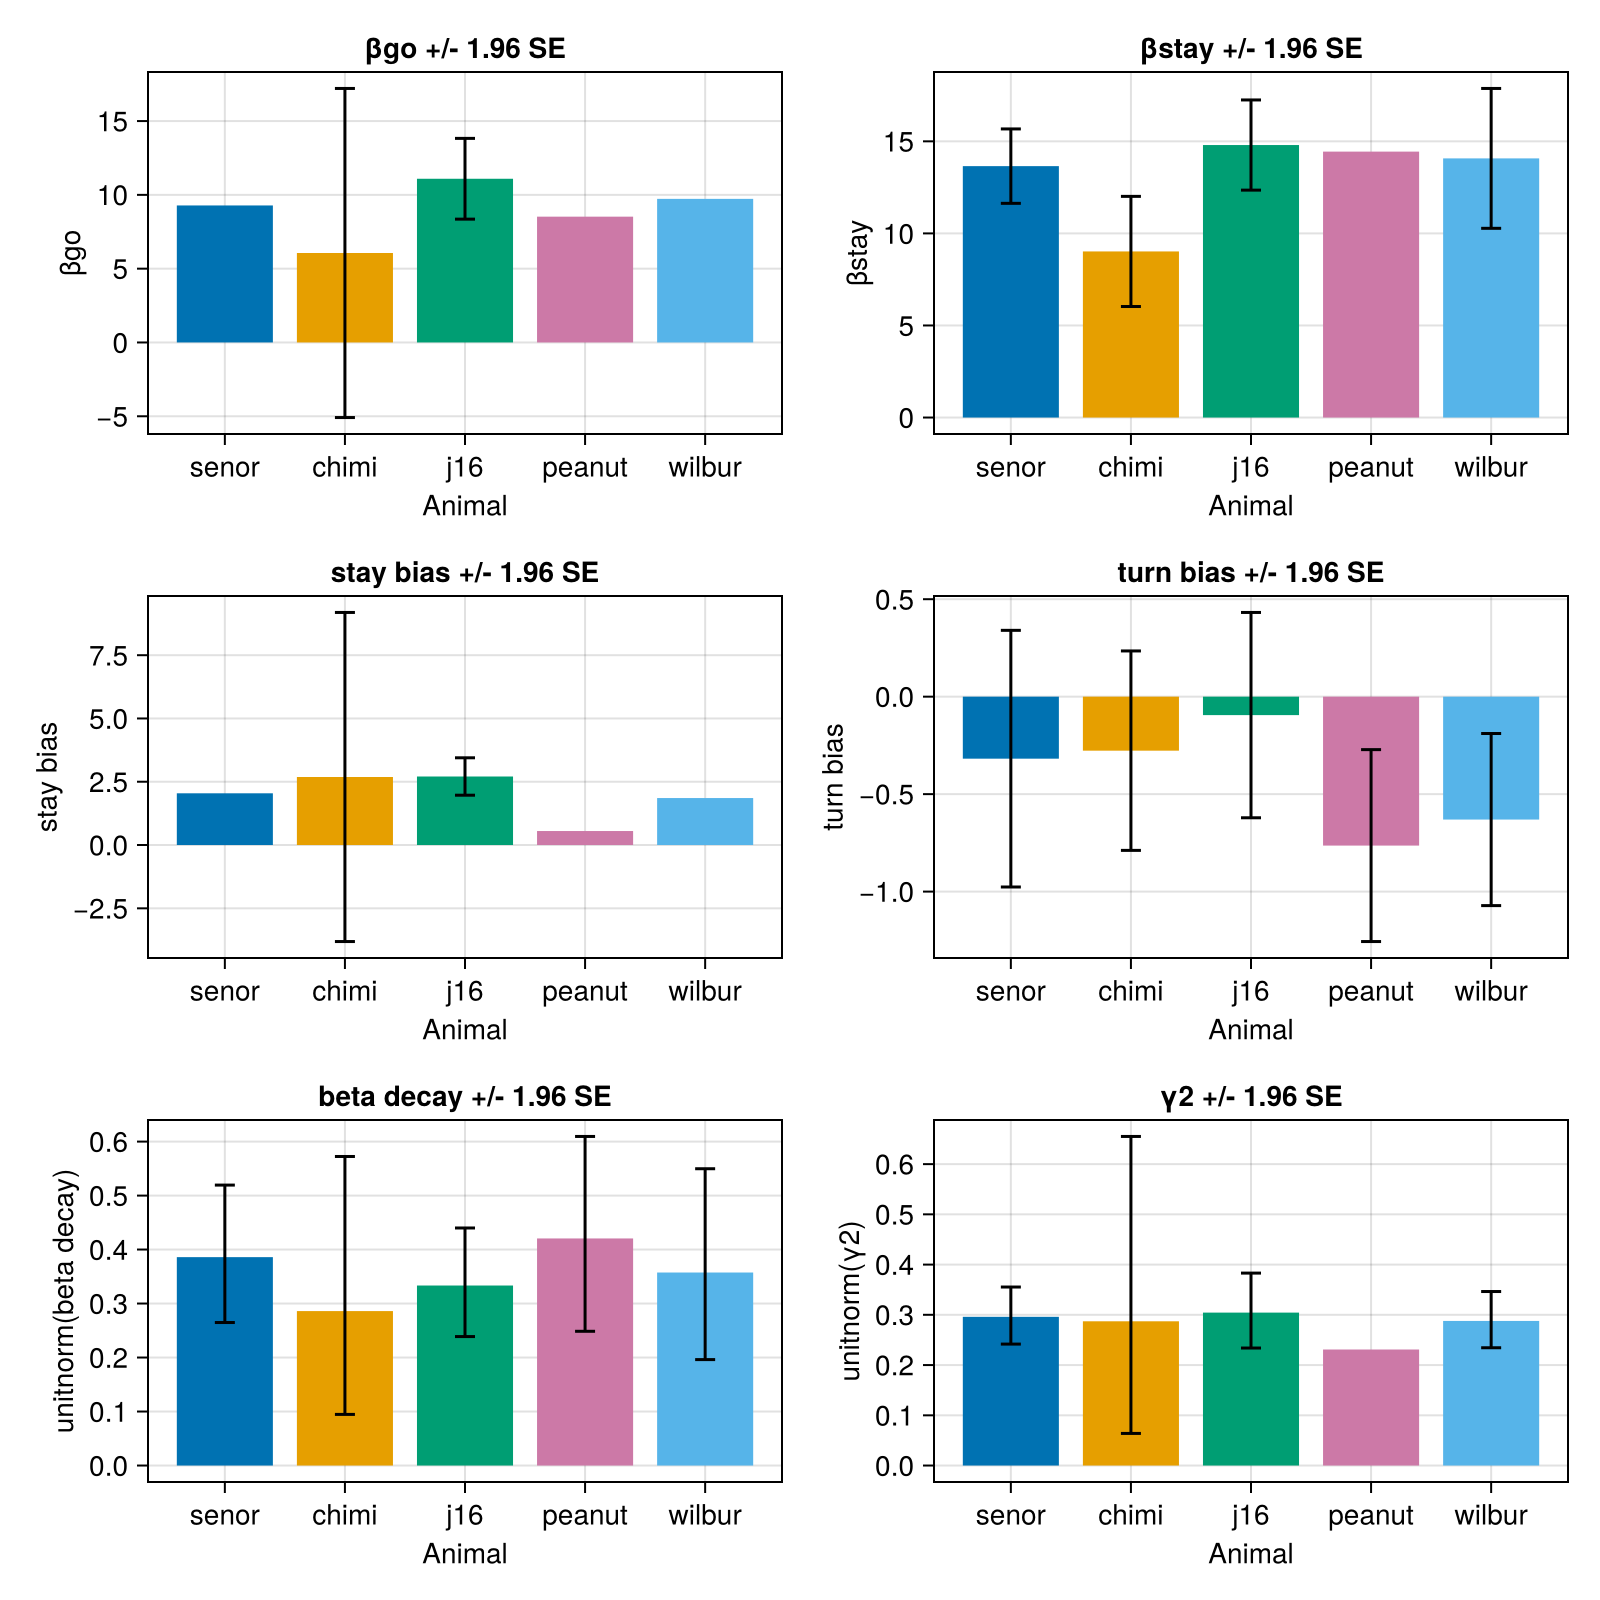

In [144]:
f = Figure(size=(800, 800))
colors = Makie.wong_colors()
ax = Axis(f[1,1], xlabel="Animal", ylabel="βgo", title="βgo +/- 1.96 SE", xticks=(1:5, animals))
barplot!(1:5, [get_beta(rs_beta[i], "βgo") for i in 1:5], color=colors[1:5])
errorbars!(1:5, [get_beta(rs_beta[i], "βgo") for i in 1:5], 1.96*[get_standarderror(rs_beta[i], "βgo") for i in 1:5], color=:black, whiskerwidth=10)

ax = Axis(f[1,2], xlabel="Animal", ylabel="βstay", title="βstay +/- 1.96 SE", xticks=(1:5, animals))
barplot!(1:5, [get_beta(rs_beta[i], "βstay") for i in 1:5], color=colors[1:5])
errorbars!(1:5, [get_beta(rs_beta[i], "βstay") for i in 1:5], 1.96*[get_standarderror(rs_beta[i], "βstay") for i in 1:5], color=:black, whiskerwidth=10)

ax = Axis(f[2,1], xlabel="Animal", ylabel="stay bias", title="stay bias +/- 1.96 SE", xticks=(1:5, animals))
barplot!(1:5, [get_beta(rs_beta[i], "stay_bias") for i in 1:5], color=colors[1:5])
errorbars!(1:5, [get_beta(rs_beta[i], "stay_bias") for i in 1:5], 1.96*[get_standarderror(rs_beta[i], "stay_bias") for i in 1:5], color=:black, whiskerwidth=10)

ax = Axis(f[2,2], xlabel="Animal", ylabel="turn bias", title="turn bias +/- 1.96 SE", xticks=(1:5, animals))
barplot!(1:5, [get_beta(rs_beta[i], "turn_bias") for i in 1:5], color=colors[1:5])
errorbars!(1:5, [get_beta(rs_beta[i], "turn_bias") for i in 1:5], 1.96*[get_standarderror(rs_beta[i], "turn_bias") for i in 1:5], color=:black, whiskerwidth=10)

ax = Axis(f[3,1], xlabel="Animal", ylabel="unitnorm(beta decay)", title="beta decay +/- 1.96 SE", xticks=(1:5, animals))
barplot!(1:5, unitnorm.([get_beta(rs_beta[i], "beta_decay") for i in 1:5]), color=colors[1:5])
rangebars!(1:5,
    unitnorm.([get_beta(rs_beta[i], "beta_decay") for i in 1:5] - 1.96*[get_standarderror(rs_beta[i], "beta_decay") for i in 1:5]), 
    unitnorm.([get_beta(rs_beta[i], "beta_decay") for i in 1:5] + 1.96*[get_standarderror(rs_beta[i], "beta_decay") for i in 1:5]), 
    color=:black, whiskerwidth=10)

ax = Axis(f[3,2], xlabel="Animal", ylabel="unitnorm(γ2)", title="γ2 +/- 1.96 SE", xticks=(1:5, animals))
barplot!(1:5, unitnorm.([get_beta(rs_beta[i], "γ2") for i in 1:5]), color=colors[1:5])
rangebars!(1:5,
    unitnorm.([get_beta(rs_beta[i], "γ2") for i in 1:5] - 1.96*[get_standarderror(rs_beta[i], "γ2") for i in 1:5]), 
    unitnorm.([get_beta(rs_beta[i], "γ2") for i in 1:5] + 1.96*[get_standarderror(rs_beta[i], "γ2") for i in 1:5]), 
    color=:black, whiskerwidth=10)
f

In [147]:
println("decay")
for i in 1:5
    println("$(animals[i]): $(unitnorm(get_beta(rs_beta[i], "beta_decay")))")
end
println()
println("γ2")
for i in 1:5
    println("$(animals[i]): $(unitnorm(get_beta(rs_beta[i], "γ2")))")
end

decay
senor: 0.38596810605308174
chimi: 0.2860653865185794
j16: 0.33341177596277144
peanut: 0.4205821737649381
wilbur: 0.3574998562804065

γ2
senor: 0.296034675121987
chimi: 0.28712664465923715
j16: 0.30441277753680007
peanut: 0.23096458726242036
wilbur: 0.28784586452009353


## Day Level

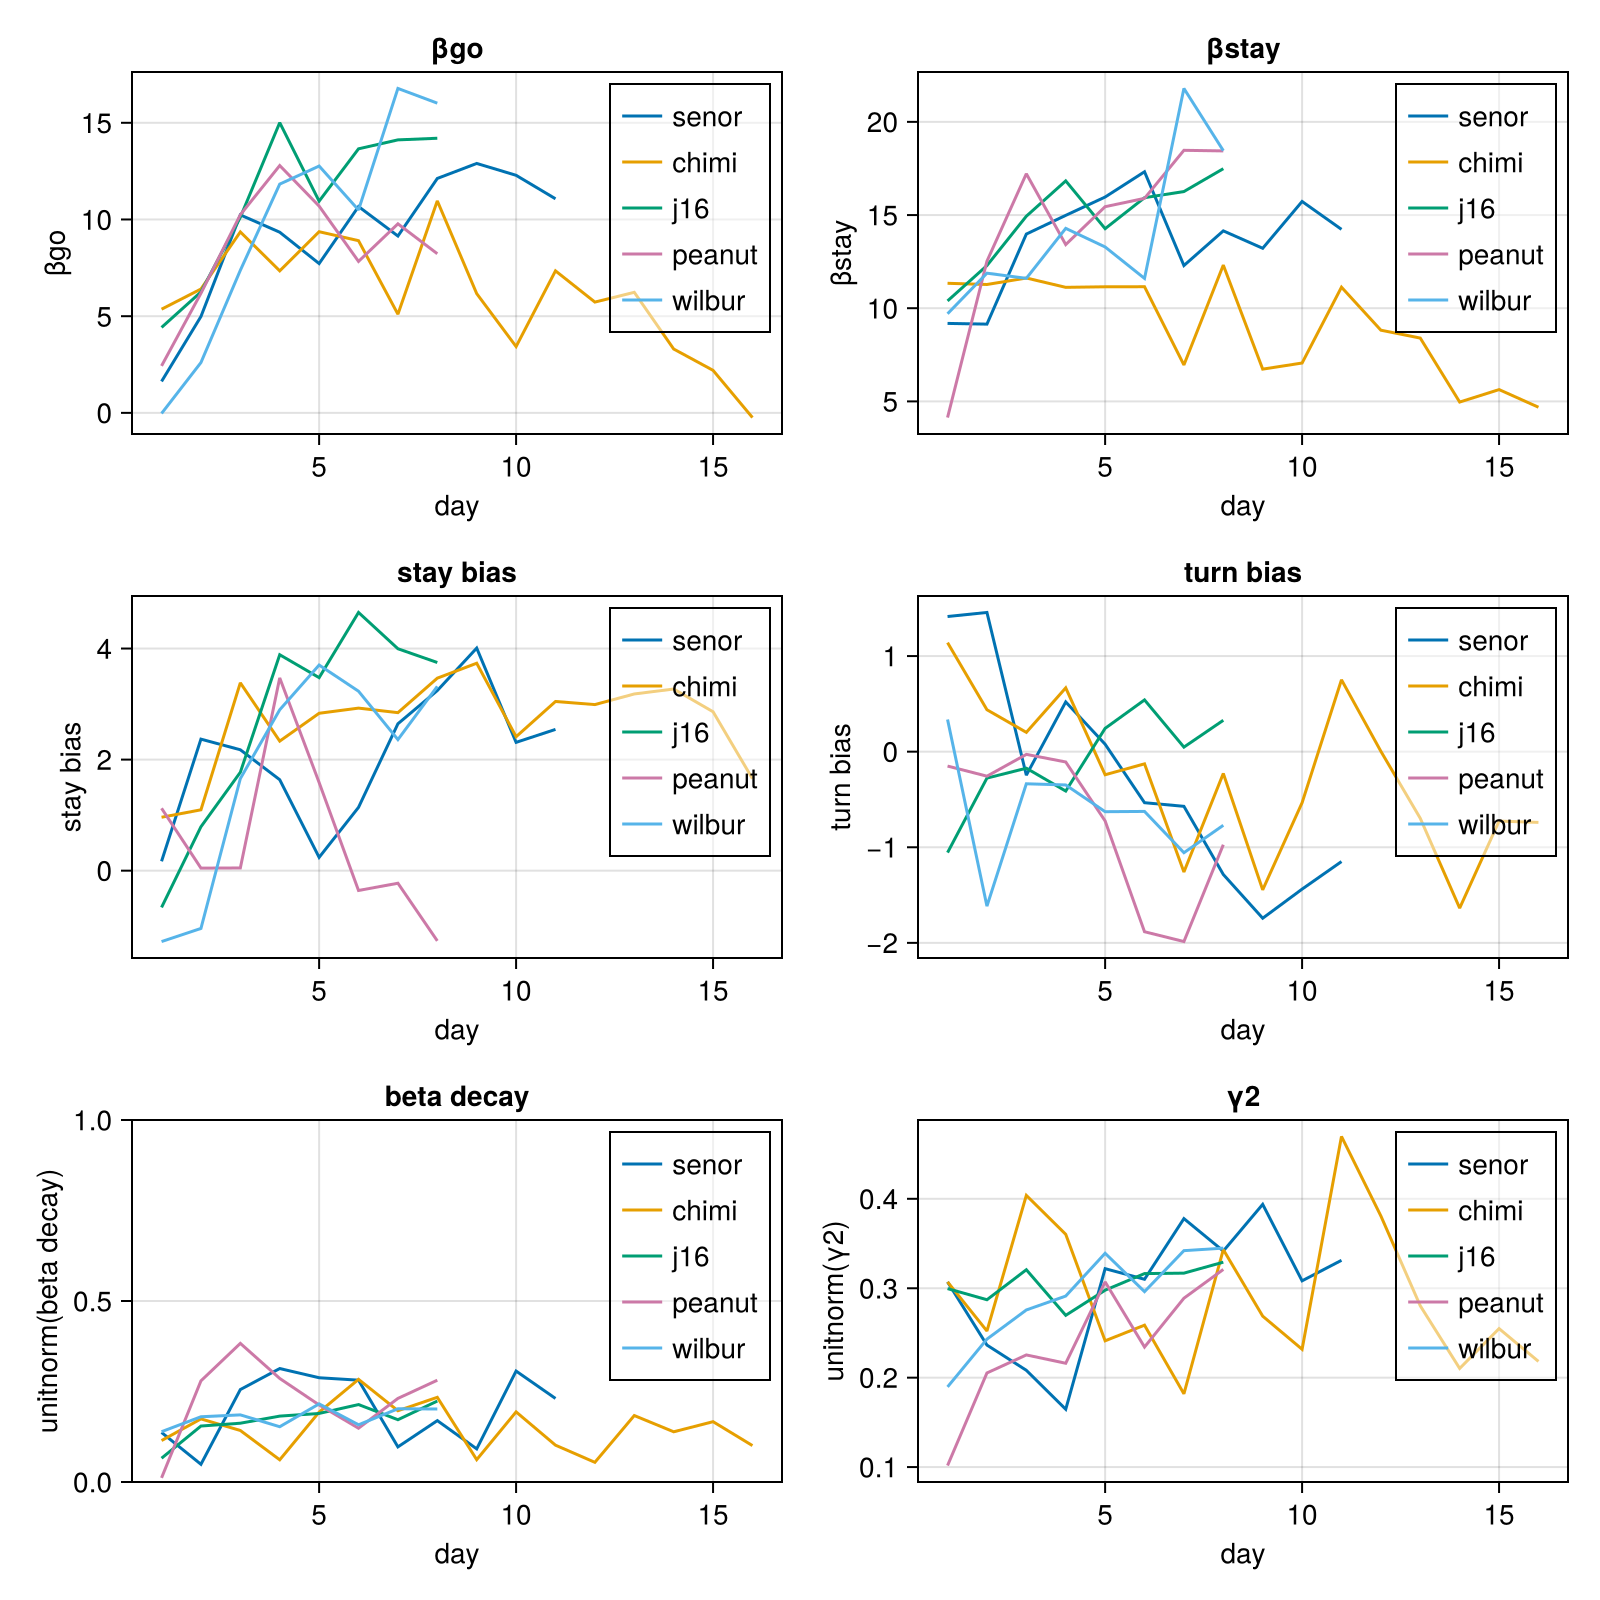

In [283]:
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.5))
f = Figure(size=(800, 800))
colors = Makie.wong_colors()
ax = Axis(f[1,1], xlabel="day", ylabel="βgo", title="βgo")
for i in 1:5
    lines!(get_all_subjects_beta(rs_beta[i], "βgo"), color=colors[i], label=animals[i])
end
axislegend(;legend_kws...)

ax = Axis(f[1,2], xlabel="day", ylabel="βstay", title="βstay")
for i in 1:5
    lines!(get_all_subjects_beta(rs_beta[i], "βstay"), color=colors[i], label=animals[i])
end
axislegend(;legend_kws...)

ax = Axis(f[2,1], xlabel="day", ylabel="stay bias", title="stay bias")
for i in 1:5
    lines!(get_all_subjects_beta(rs_beta[i], "stay_bias"), color=colors[i], label=animals[i])
end
axislegend(;legend_kws...)

ax = Axis(f[2,2], xlabel="day", ylabel="turn bias", title="turn bias")
for i in 1:5
    lines!(get_all_subjects_beta(rs_beta[i], "turn_bias"), color=colors[i], label=animals[i])
end
axislegend(;legend_kws...)

ax = Axis(f[3,1], xlabel="day", ylabel="unitnorm(beta decay)", title="beta decay")
for i in 1:5
    lines!(unitnorm.(get_all_subjects_beta(rs_beta[i], "beta_decay")) ./ 2, color=colors[i], label=animals[i])
end
axislegend(;legend_kws...)
ylims!(ax, (0, 1))

ax = Axis(f[3,2], xlabel="day", ylabel="unitnorm(γ2)", title="γ2")
for i in 1:5
    lines!(unitnorm.(get_all_subjects_beta(rs_beta[i], "γ2")), color=colors[i], label=animals[i])
end
axislegend(;legend_kws...)
f

# Measures of Uncertainty

In [150]:
function zscore(x)
    (x .- mean(x)) ./ std(x)
end

zscore (generic function with 1 method)

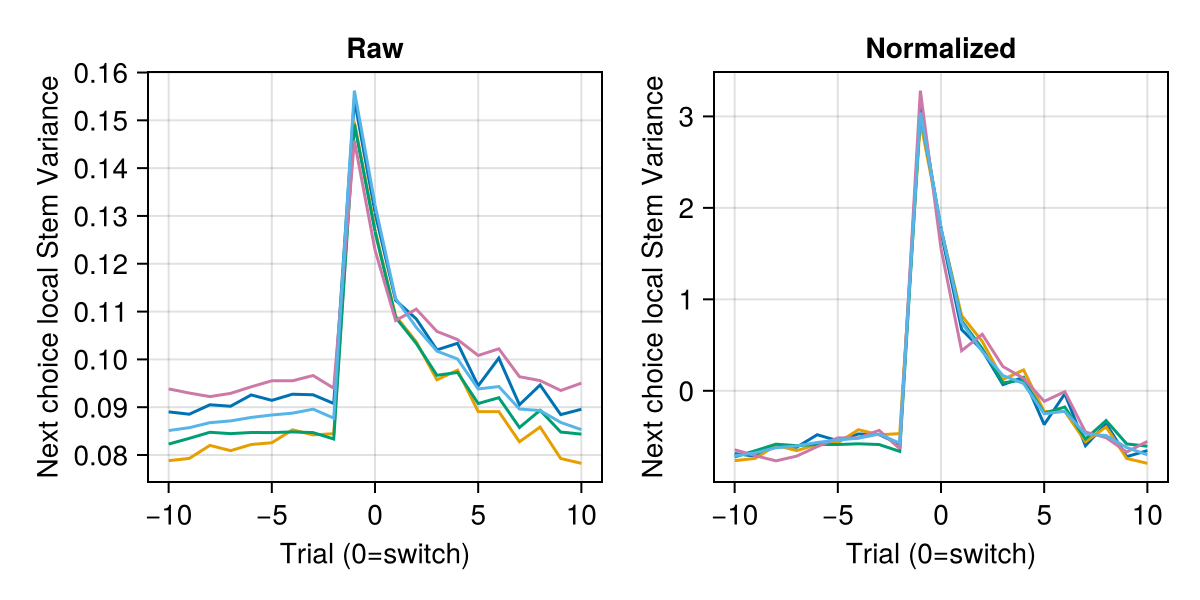

In [151]:
f = Figure(size=(600,300))
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.5))
colors = Makie.wong_colors()

ax1 = Axis(f[1,1], xlabel="Trial (0=switch)", ylabel="Next choice local Stem Variance", title="Raw")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    next_choice_local_variance_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :next_choice_local_variance => mean => :next_choice_local_variance)
    next_choice_local_variance_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :next_choice_local_variance => mean => :next_choice_local_variance)

    lines!(-next_choice_local_variance_by_day_q1_pre.n_pre_switch, next_choice_local_variance_by_day_q1_pre.next_choice_local_variance, color=colors[i])
    lines!(next_choice_local_variance_by_day_q1_post.n_post_switch, next_choice_local_variance_by_day_q1_post.next_choice_local_variance, color=colors[i])
end

ax1 = Axis(f[1,2], xlabel="Trial (0=switch)", ylabel="Next choice local Stem Variance", title="Normalized")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    next_choice_local_variance_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :next_choice_local_variance => mean => :next_choice_local_variance)
    next_choice_local_variance_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :next_choice_local_variance => mean => :next_choice_local_variance)

    adj = zscore(vcat(next_choice_local_variance_by_day_q1_pre.next_choice_local_variance, next_choice_local_variance_by_day_q1_post.next_choice_local_variance))
    lines!(-next_choice_local_variance_by_day_q1_pre.n_pre_switch, adj[1:11], color=colors[i])
    lines!(next_choice_local_variance_by_day_q1_post.n_post_switch, adj[12:end], color=colors[i])
end

f

Mean and variance update sizes around switches

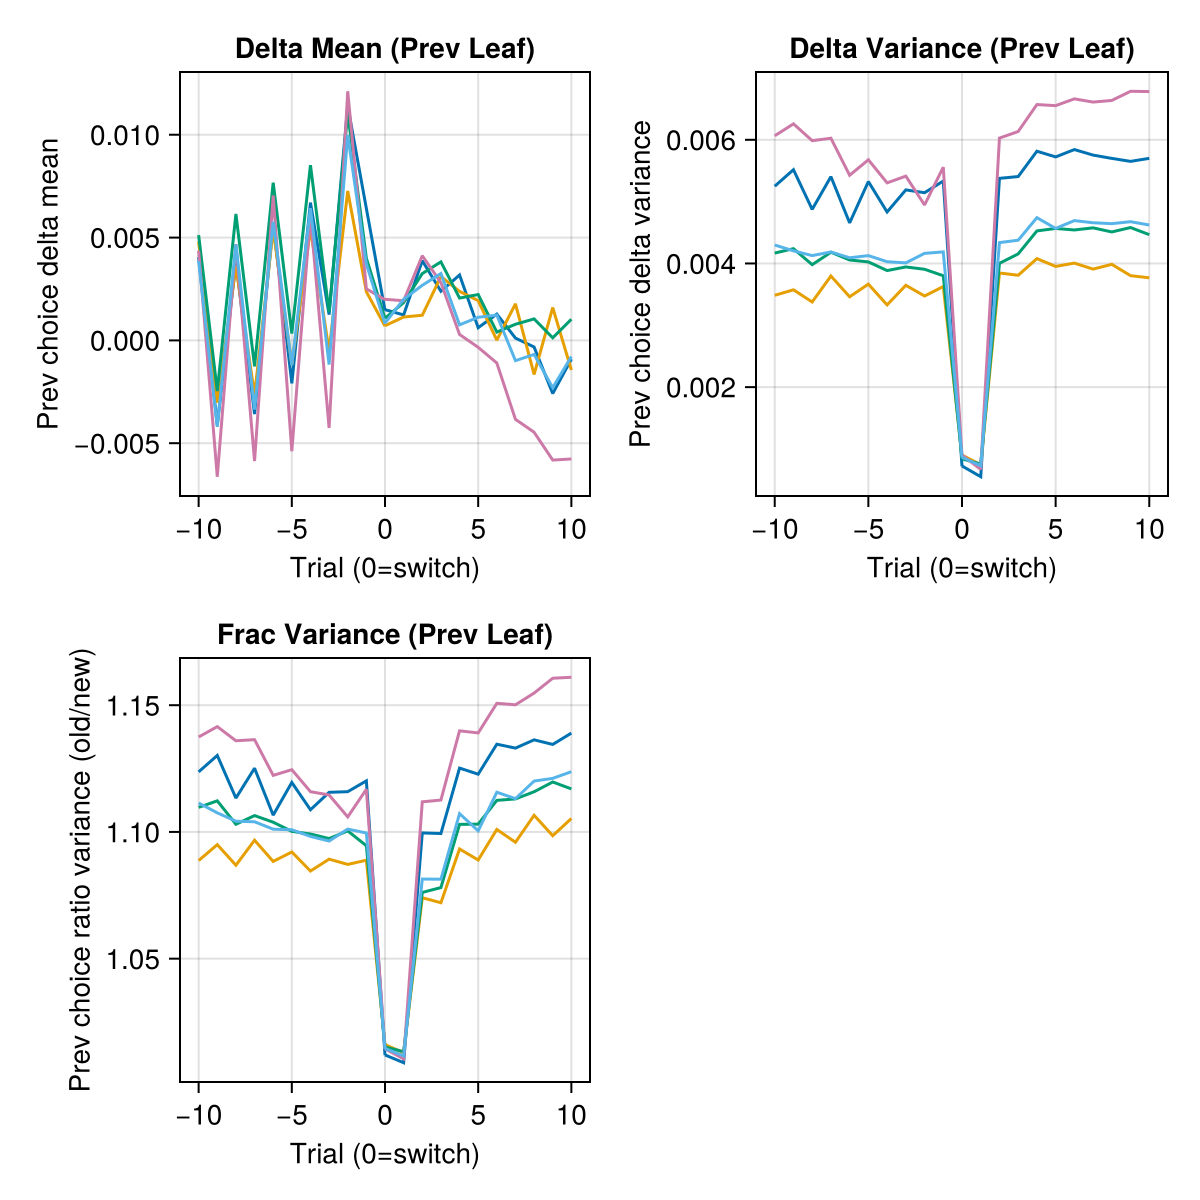

In [152]:
f = Figure(size=(600,600))
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.5))
colors = Makie.wong_colors()

ax1 = Axis(f[1,1], xlabel="Trial (0=switch)", ylabel="Prev choice delta mean", title="Delta Mean (Prev Leaf)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    prev_leaf_mu_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :prev_leaf_mu_delta => mean => :prev_leaf_mu_delta)
    prev_leaf_mu_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :prev_leaf_mu_delta => mean => :prev_leaf_mu_delta)

    lines!(-prev_leaf_mu_delta_by_day_q1_pre.n_pre_switch, prev_leaf_mu_delta_by_day_q1_pre.prev_leaf_mu_delta, color=colors[i])
    lines!(prev_leaf_mu_delta_by_day_q1_post.n_post_switch, prev_leaf_mu_delta_by_day_q1_post.prev_leaf_mu_delta, color=colors[i])
end

ax2 = Axis(f[1,2], xlabel="Trial (0=switch)", ylabel="Prev choice delta variance", title="Delta Variance (Prev Leaf)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    prev_leaf_var_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :prev_leaf_var_delta => mean => :prev_leaf_var_delta)
    prev_leaf_var_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :prev_leaf_var_delta => mean => :prev_leaf_var_delta)

    lines!(-prev_leaf_var_delta_by_day_q1_pre.n_pre_switch, prev_leaf_var_delta_by_day_q1_pre.prev_leaf_var_delta, color=colors[i])
    lines!(prev_leaf_var_delta_by_day_q1_post.n_post_switch, prev_leaf_var_delta_by_day_q1_post.prev_leaf_var_delta, color=colors[i])
end

ax3 = Axis(f[2,1], xlabel="Trial (0=switch)", ylabel="Prev choice ratio variance (old/new)", title="Frac Variance (Prev Leaf)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    prev_leaf_var_ratio_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :prev_leaf_var_ratio => mean => :prev_leaf_var_ratio)
    prev_leaf_var_ratio_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :prev_leaf_var_ratio => mean => :prev_leaf_var_ratio)

    lines!(-prev_leaf_var_ratio_by_day_q1_pre.n_pre_switch, prev_leaf_var_ratio_by_day_q1_pre.prev_leaf_var_ratio, color=colors[i])
    lines!(prev_leaf_var_ratio_by_day_q1_post.n_post_switch, prev_leaf_var_ratio_by_day_q1_post.prev_leaf_var_ratio, color=colors[i])
end

f

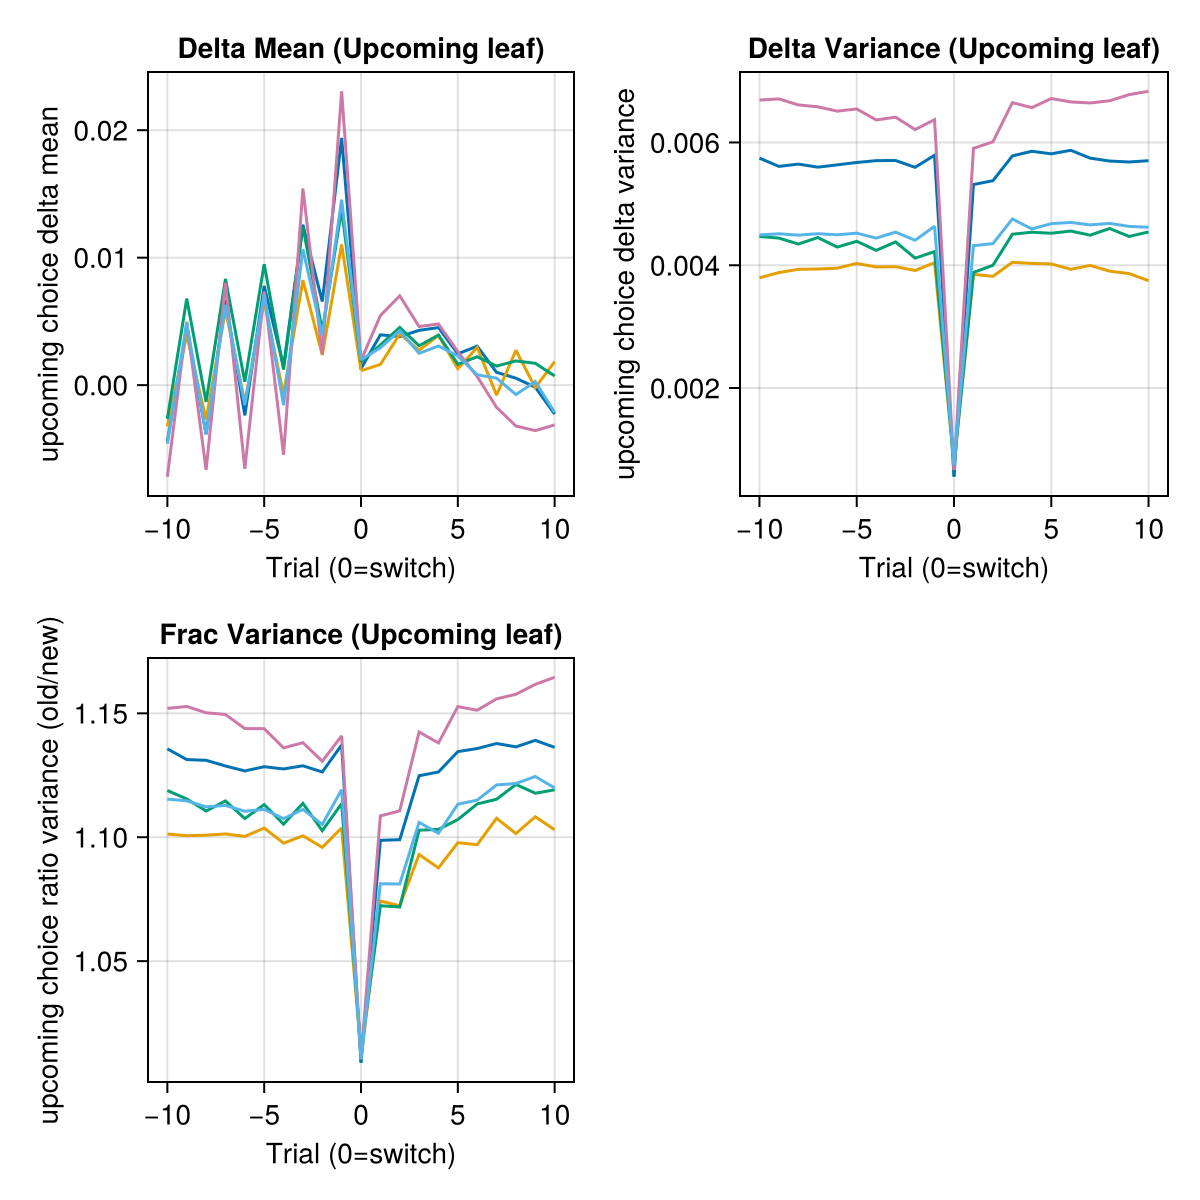

In [153]:
f = Figure(size=(600,600))
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.5))
colors = Makie.wong_colors()

ax1 = Axis(f[1,1], xlabel="Trial (0=switch)", ylabel="upcoming choice delta mean", title="Delta Mean (Upcoming leaf)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    upcoming_leaf_mu_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :upcoming_leaf_mu_delta => mean => :upcoming_leaf_mu_delta)
    upcoming_leaf_mu_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :upcoming_leaf_mu_delta => mean => :upcoming_leaf_mu_delta)

    lines!(-upcoming_leaf_mu_delta_by_day_q1_pre.n_pre_switch, upcoming_leaf_mu_delta_by_day_q1_pre.upcoming_leaf_mu_delta, color=colors[i])
    lines!(upcoming_leaf_mu_delta_by_day_q1_post.n_post_switch, upcoming_leaf_mu_delta_by_day_q1_post.upcoming_leaf_mu_delta, color=colors[i])
end

ax2 = Axis(f[1,2], xlabel="Trial (0=switch)", ylabel="upcoming choice delta variance", title="Delta Variance (Upcoming leaf)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    upcoming_leaf_var_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :upcoming_leaf_var_delta => mean => :upcoming_leaf_var_delta)
    upcoming_leaf_var_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :upcoming_leaf_var_delta => mean => :upcoming_leaf_var_delta)

    lines!(-upcoming_leaf_var_delta_by_day_q1_pre.n_pre_switch, upcoming_leaf_var_delta_by_day_q1_pre.upcoming_leaf_var_delta, color=colors[i])
    lines!(upcoming_leaf_var_delta_by_day_q1_post.n_post_switch, upcoming_leaf_var_delta_by_day_q1_post.upcoming_leaf_var_delta, color=colors[i])
end

ax3 = Axis(f[2,1], xlabel="Trial (0=switch)", ylabel="upcoming choice ratio variance (old/new)", title="Frac Variance (Upcoming leaf)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    upcoming_leaf_var_ratio_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :upcoming_leaf_var_ratio => mean => :upcoming_leaf_var_ratio)
    upcoming_leaf_var_ratio_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :upcoming_leaf_var_ratio => mean => :upcoming_leaf_var_ratio)

    lines!(-upcoming_leaf_var_ratio_by_day_q1_pre.n_pre_switch, upcoming_leaf_var_ratio_by_day_q1_pre.upcoming_leaf_var_ratio, color=colors[i])
    lines!(upcoming_leaf_var_ratio_by_day_q1_post.n_post_switch, upcoming_leaf_var_ratio_by_day_q1_post.upcoming_leaf_var_ratio, color=colors[i])
end

f

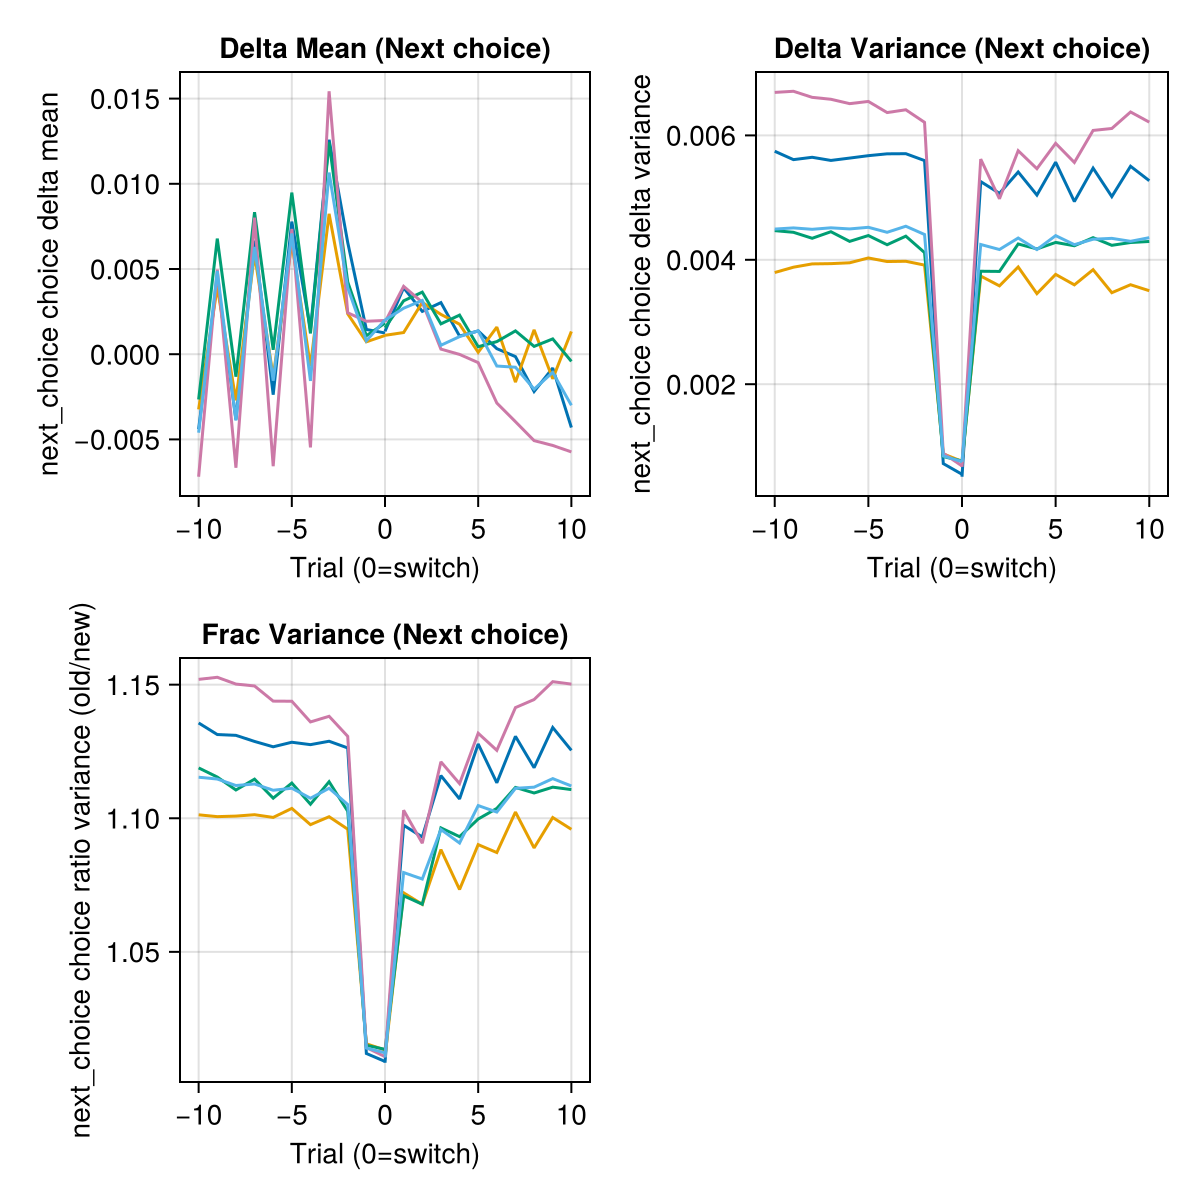

In [154]:
f = Figure(size=(600,600))
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.5))
colors = Makie.wong_colors()

ax1 = Axis(f[1,1], xlabel="Trial (0=switch)", ylabel="next_choice choice delta mean", title="Delta Mean (Next choice)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    next_choice_leaf_mu_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :next_choice_leaf_mu_delta => mean => :next_choice_leaf_mu_delta)
    next_choice_leaf_mu_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :next_choice_leaf_mu_delta => mean => :next_choice_leaf_mu_delta)

    lines!(-next_choice_leaf_mu_delta_by_day_q1_pre.n_pre_switch, next_choice_leaf_mu_delta_by_day_q1_pre.next_choice_leaf_mu_delta, color=colors[i])
    lines!(next_choice_leaf_mu_delta_by_day_q1_post.n_post_switch, next_choice_leaf_mu_delta_by_day_q1_post.next_choice_leaf_mu_delta, color=colors[i])
end

ax2 = Axis(f[1,2], xlabel="Trial (0=switch)", ylabel="next_choice choice delta variance", title="Delta Variance (Next choice)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    next_choice_leaf_var_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :next_choice_leaf_var_delta => mean => :next_choice_leaf_var_delta)
    next_choice_leaf_var_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :next_choice_leaf_var_delta => mean => :next_choice_leaf_var_delta)

    lines!(-next_choice_leaf_var_delta_by_day_q1_pre.n_pre_switch, next_choice_leaf_var_delta_by_day_q1_pre.next_choice_leaf_var_delta, color=colors[i])
    lines!(next_choice_leaf_var_delta_by_day_q1_post.n_post_switch, next_choice_leaf_var_delta_by_day_q1_post.next_choice_leaf_var_delta, color=colors[i])
end

ax3 = Axis(f[2,1], xlabel="Trial (0=switch)", ylabel="next_choice choice ratio variance (old/new)", title="Frac Variance (Next choice)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    next_choice_leaf_var_ratio_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :next_choice_leaf_var_ratio => mean => :next_choice_leaf_var_ratio)
    next_choice_leaf_var_ratio_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :next_choice_leaf_var_ratio => mean => :next_choice_leaf_var_ratio)

    lines!(-next_choice_leaf_var_ratio_by_day_q1_pre.n_pre_switch, next_choice_leaf_var_ratio_by_day_q1_pre.next_choice_leaf_var_ratio, color=colors[i])
    lines!(next_choice_leaf_var_ratio_by_day_q1_post.n_post_switch, next_choice_leaf_var_ratio_by_day_q1_post.next_choice_leaf_var_ratio, color=colors[i])
end

f

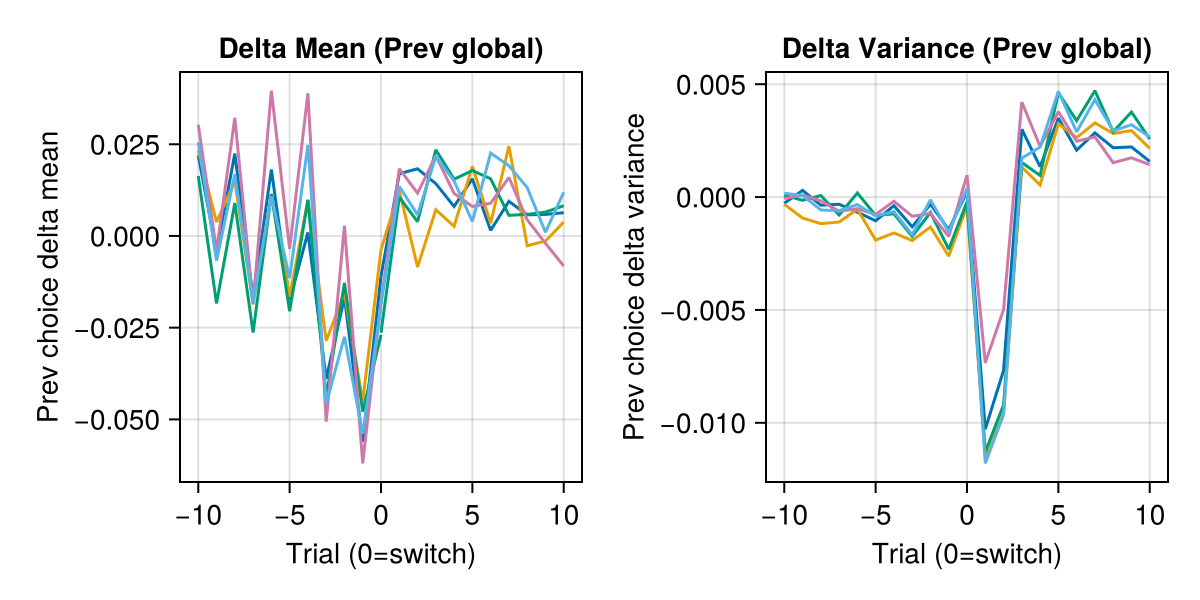

In [155]:
f = Figure(size=(600,300))
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.5))
colors = Makie.wong_colors()

ax1 = Axis(f[1,1], xlabel="Trial (0=switch)", ylabel="Prev choice delta mean", title="Delta Mean (Prev global)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    prev_global_mu_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :prev_global_mu_delta => mean => :prev_global_mu_delta)
    prev_global_mu_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :prev_global_mu_delta => mean => :prev_global_mu_delta)

    lines!(-prev_global_mu_delta_by_day_q1_pre.n_pre_switch, prev_global_mu_delta_by_day_q1_pre.prev_global_mu_delta, color=colors[i])
    lines!(prev_global_mu_delta_by_day_q1_post.n_post_switch, prev_global_mu_delta_by_day_q1_post.prev_global_mu_delta, color=colors[i])
end

ax2 = Axis(f[1,2], xlabel="Trial (0=switch)", ylabel="Prev choice delta variance", title="Delta Variance (Prev global)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    prev_global_var_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :prev_global_var_delta => mean => :prev_global_var_delta)
    prev_global_var_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :prev_global_var_delta => mean => :prev_global_var_delta)

    lines!(-prev_global_var_delta_by_day_q1_pre.n_pre_switch, prev_global_var_delta_by_day_q1_pre.prev_global_var_delta, color=colors[i])
    lines!(prev_global_var_delta_by_day_q1_post.n_post_switch, prev_global_var_delta_by_day_q1_post.prev_global_var_delta, color=colors[i])
end


f

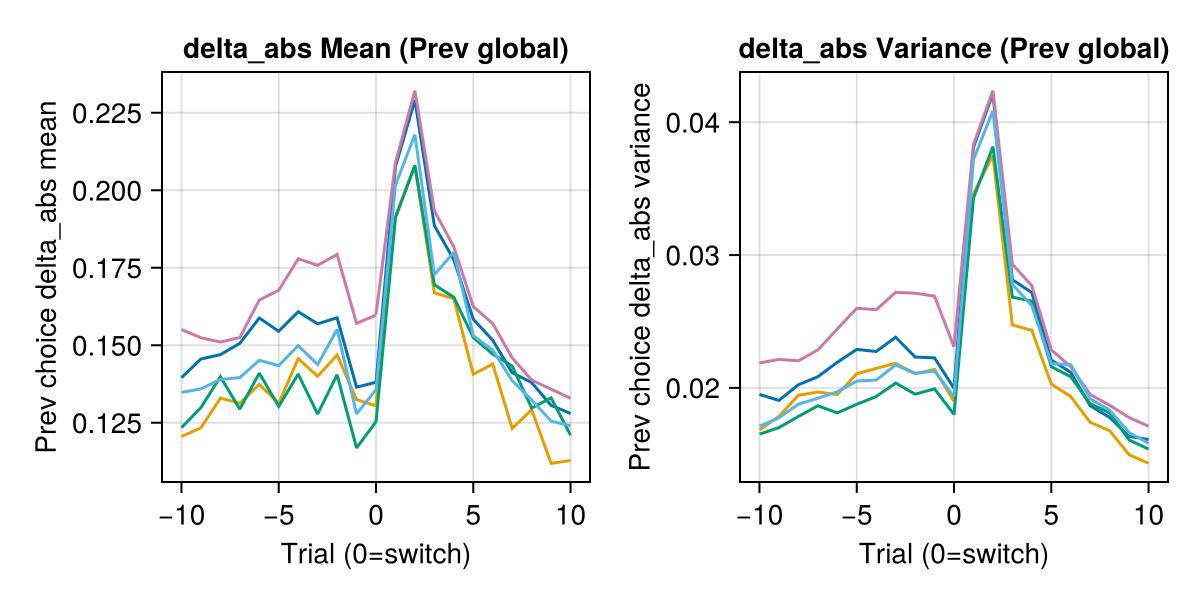

In [156]:
f = Figure(size=(600,300))
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.5))
colors = Makie.wong_colors()

ax1 = Axis(f[1,1], xlabel="Trial (0=switch)", ylabel="Prev choice delta_abs mean", title="delta_abs Mean (Prev global)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    prev_global_mu_delta_abs_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :prev_global_mu_delta_abs => mean => :prev_global_mu_delta_abs)
    prev_global_mu_delta_abs_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :prev_global_mu_delta_abs => mean => :prev_global_mu_delta_abs)

    lines!(-prev_global_mu_delta_abs_by_day_q1_pre.n_pre_switch, prev_global_mu_delta_abs_by_day_q1_pre.prev_global_mu_delta_abs, color=colors[i])
    lines!(prev_global_mu_delta_abs_by_day_q1_post.n_post_switch, prev_global_mu_delta_abs_by_day_q1_post.prev_global_mu_delta_abs, color=colors[i])
end

ax2 = Axis(f[1,2], xlabel="Trial (0=switch)", ylabel="Prev choice delta_abs variance", title="delta_abs Variance (Prev global)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    prev_global_var_delta_abs_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :prev_global_var_delta_abs => mean => :prev_global_var_delta_abs)
    prev_global_var_delta_abs_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :prev_global_var_delta_abs => mean => :prev_global_var_delta_abs)

    lines!(-prev_global_var_delta_abs_by_day_q1_pre.n_pre_switch, prev_global_var_delta_abs_by_day_q1_pre.prev_global_var_delta_abs, color=colors[i])
    lines!(prev_global_var_delta_abs_by_day_q1_post.n_post_switch, prev_global_var_delta_abs_by_day_q1_post.prev_global_var_delta_abs, color=colors[i])
end


f

# Comparison with HMM

In [198]:
rs_hmm_local_g2 = [load("$(filepath)/results/hmm_independentsamedist_biases/hmm_independentsamedist_leaf_stay_turn_leafspatial_γ2_$(animal)_full.jld2", "results") for animal in animals];
rs_hmm_global_g2 = [load("$(filepath)/results/hmm_biases/hmm_leaf_stay_turn_leafspatial_γ2_$(animal)_full.jld2", "results") for animal in animals];

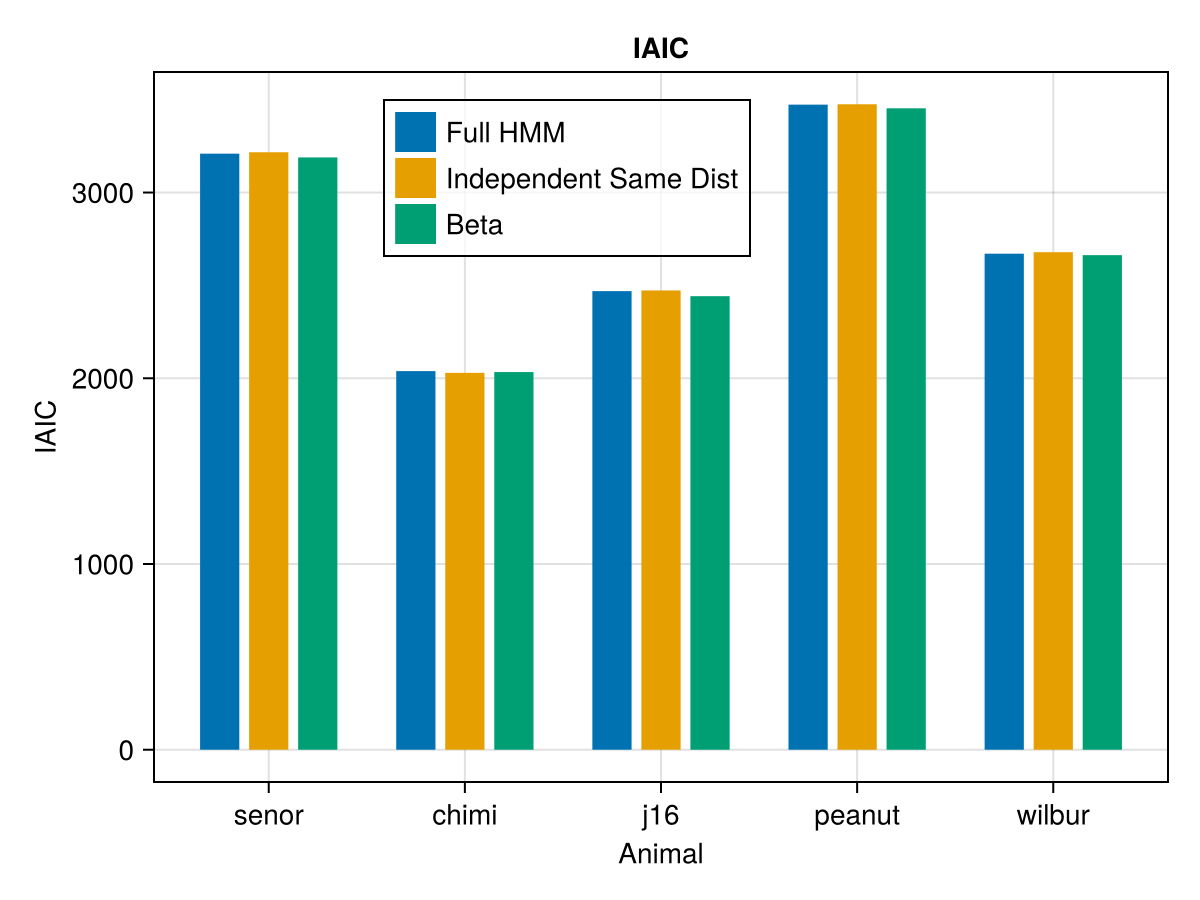

In [199]:
iaics_hmm_global_g2 = iaic.(rs_hmm_global_g2)
iaics_hmm_local_g2 = iaic.(rs_hmm_local_g2)
iaics_beta = iaic.(rs_beta)

f = Figure()
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.75))
colors = Makie.wong_colors()
ax = Axis(f[1,1], xlabel="Animal", ylabel="IAIC", title="IAIC", xticks=([2,6,10,14,18], animals))
for i in 1:5
    x = (1:3) .+ ((i-1) * 4)
    barplot!(x[1], iaics_hmm_global_g2[i], color=colors[1], label=["Full HMM"], width=1.0)
    barplot!(x[2], iaics_hmm_local_g2[i], color=colors[2], label=["Independent Same Dist"], width=1.0)
    barplot!(x[3], iaics_beta[i], color=colors[3], label=["Beta"], width=1.0)
end
axislegend(merge=true; legend_kws..., position = (0.35, 0.97))
f

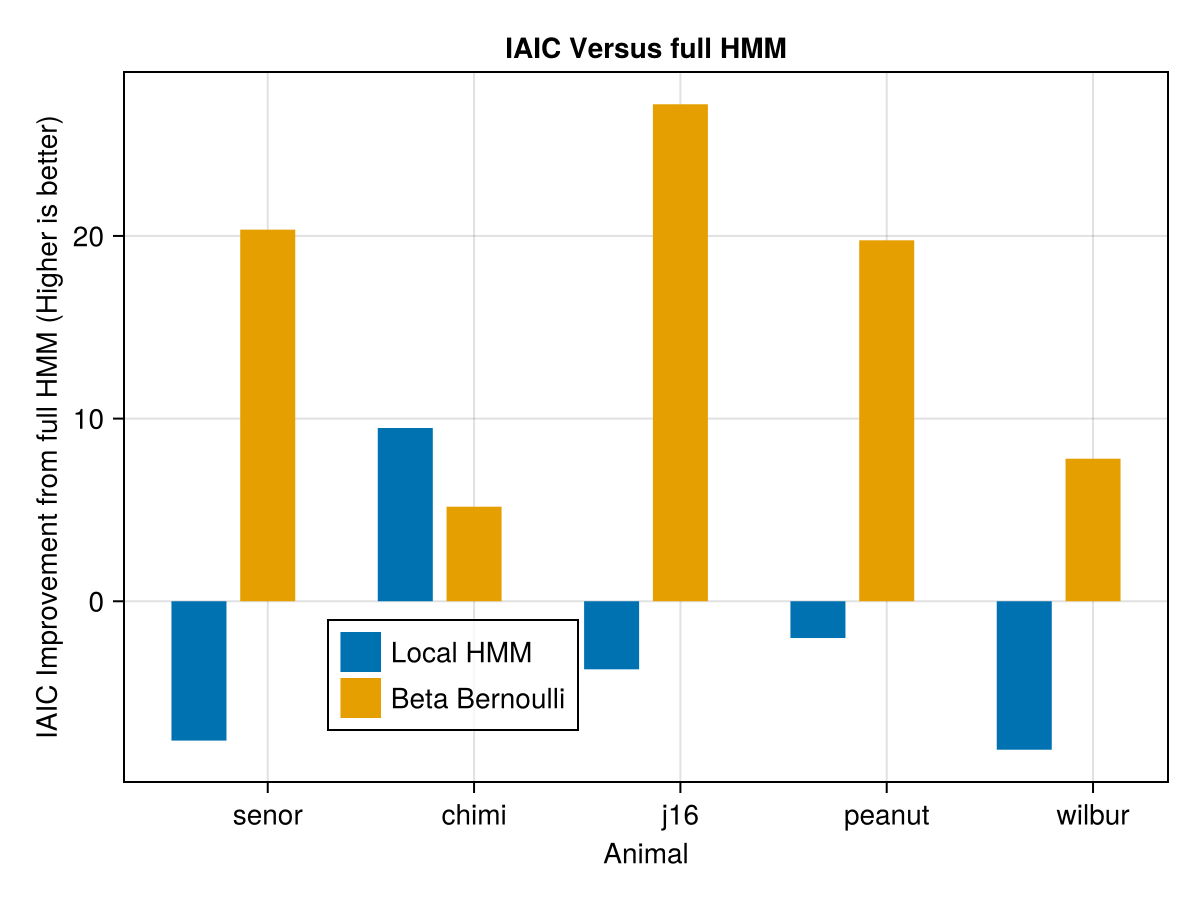

In [202]:
iaics_hmm_global_g2 = iaic.(rs_hmm_global_g2)
iaics_hmm_local_g2 = iaic.(rs_hmm_local_g2)
iaics_beta = iaic.(rs_beta)

f = Figure()
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.75))
colors = Makie.wong_colors()
ax = Axis(f[1,1], xlabel="Animal", ylabel="IAIC Improvement from full HMM (Higher is better)", title="IAIC Versus full HMM", xticks=([2,5,8,11,14], animals))
for i in 1:5
    x = (1:2) .+ ((i-1) * 3)
    barplot!(x[1], iaics_hmm_global_g2[i] - iaics_hmm_local_g2[i], color=colors[1], label=["Local HMM"], width=1.0)
    barplot!(x[2], iaics_hmm_global_g2[i] - iaics_beta[i], color=colors[2], label=["Beta Bernoulli"], width=1.0)
    # barplot!(x[2], iaics_hmm_local_g2[i], color=colors[2], label=["Independent Same Dist"], width=1.0)
    # barplot!(x[3], iaics_beta[i], color=colors[3], label=["Beta"], width=1.0)
end
axislegend(merge=true; legend_kws..., position = (0.25, 0.07))
f

## LOO-CV

In [284]:
rs_hmm_loocv = [load("$(filepath)/results/hmm_biases_loocv/hmm_leaf_stay_turn_leafspatial_$(animal)_full_loocv.jld2", "results_loocv") for animal in animals];
rs_hmm_g2_loocv = [load("$(filepath)/results/hmm_biases_loocv/hmm_leaf_stay_turn_leafspatial_γ2_$(animal)_full_loocv.jld2", "results_loocv") for animal in animals];
rs_beta_loocv = [load("$(filepath)/results/beta_bernoulli_loocv/beta_lik_leaf_stay_turn_leafspatial_decay_γ2_$(animal)_full_loocv.jld2", "results_loocv") for animal in animals];

rs_hmm_local_loocv = []
for i in 1:5
    n_days = size(rs_hmm_loocv[i], 1)
    x = [
        load("$(filepath)/results/hmm_independentsamedist_biases_loocv/hmm_independentsamedist_leaf_stay_turn_leafspatial_$(animals[i])_full_loocv_s$(day).jld2", "results_loocv")
        for day in 1:n_days
    ]
    push!(rs_hmm_local_loocv, x)
end

rs_hmm_local_g2_loocv = []
for i in 1:5
    n_days = size(rs_hmm_loocv[i], 1)
    x = [
        load("$(filepath)/results/hmm_independentsamedist_biases_loocv/hmm_independentsamedist_leaf_stay_turn_leafspatial_γ2_$(animals[i])_full_loocv_s$(day).jld2", "results_loocv")
        for day in 1:n_days
    ]
    push!(rs_hmm_local_g2_loocv, x)
end

In [288]:
rs_hmm_loocv

5-element Vector{Vector{Float64}}:
 [317.83095153919476, 269.2795391720289, 357.41332410779086, 307.04053407184506, 408.19985418396175, 283.5865604918554, 259.7972076281842, 273.3722347109577, 203.94970333272016, 337.5052163197952, 203.75545538523227]
 [162.68804588276004, 186.31125875777624, 72.25908444962586, 78.73072238202187, 170.7871451206519, 112.29054106900232, 137.9131944177601, 142.42310480145434, 120.92461077192536, 157.63364996268112, 133.353234102573, 122.9755119553826, 119.81893768653637, 79.17764213305222, 106.30012001818268, 108.20204823553577]
 [422.17433521094534, 409.37073058657904, 369.39388738529175, 308.12250180295683, 249.50800679864645, 183.32443615839497, 241.91480397508215, 290.8880263785463]
 [441.3026714617104, 572.6766391935078, 532.2446649483253, 448.3184313263076, 383.3374692067807, 406.3341864323588, 295.54859344179005, 422.84630300808436]
 [477.4973026516349, 426.6620572272007, 406.50124059470375, 280.5230968930444, 344.56964729459764, 285.0118406279519,

In [289]:
rs_hmm_g2_loocv

5-element Vector{Vector{Float64}}:
 [313.9293004470381, 269.0369031598475, 357.2779337786129, 307.4217948966597, 404.43009909471755, 282.2258060082756, 258.10782089267263, 273.89111888703917, 202.03716734183303, 337.40820821434005, 203.13653779079414]
 [159.39420789301815, 184.97714986304314, 71.3141526141369, 78.20706378757896, 171.57843036414133, 113.1420389548265, 137.99915631982697, 140.7614224983914, 121.60199556325813, 158.14659644161463, 131.4091324663704, 124.22534032895702, 120.21634742362983, 78.48859309246949, 106.38322377561323, 109.23758399171939]
 [416.24243192383506, 404.80911810407747, 368.30562776396806, 309.3145252618625, 249.38705473943986, 183.1573035112857, 241.9996741617535, 288.8480933759769]
 [441.0044635182805, 569.8668296104794, 532.1598224291786, 452.47353273074566, 381.1376679154346, 407.0703804813448, 295.9061312093601, 418.89406493381443]
 [481.7245683546506, 426.4519226003552, 402.1417209242151, 281.13786349206623, 341.1913561957597, 283.7621177605588, 26

In [291]:
rs_hmm_local_loocv

5-element Vector{Any}:
 [327.85993944209434, 267.82698437389, 370.3663014332263, 303.8471243856857, 429.55799127516156, 307.1515441549553, 265.5358370004111, 285.93736192295864, 217.90181912437174, 347.79103363358354, 217.96436921890574]
 [164.93823529886012, 192.3792464705791, 76.82277844345872, 79.65881053568495, 173.80055901226396, 114.77073083311883, 140.1707818893544, 150.9242827232455, 120.88294648899146, 156.94775126178465, 143.1423635053148, 126.39460687771596, 120.49752361714451, 78.26144941612114, 105.2722605895421, 110.15915430112467]
 [417.1735362275762, 411.9911717674915, 388.8601535826374, 320.10670267126125, 256.8851795716504, 189.72476705775983, 258.3342467657136, 311.8692061988215]
 [433.93425635035555, 599.8376367462024, 555.451632002376, 455.4589648911614, 406.58638857741164, 423.3823829388946, 322.72087746041535, 454.8160666566839]
 [476.6330954391976, 435.4303744754683, 420.13445748538527, 292.8532667917156, 353.5070618883142, 294.5858530702747, 303.08197767578037,

In [292]:
rs_hmm_local_g2_loocv

5-element Vector{Any}:
 [320.7123308458004, 270.17211541724055, 360.6221130471862, 306.700133174909, 404.5389087482231, 288.6212921908774, 257.54226463638327, 271.8727295289615, 202.77186488508968, 337.6569512438174, 203.66977801513656]
 [157.55454241549737, 184.97147965945967, 73.07349147321128, 76.2079790830076, 172.05357999978276, 114.94264399889443, 137.63749977600816, 141.79851821313355, 118.18497919699476, 155.87041059010556, 132.84204280897103, 119.28451633265948, 121.20509285092488, 76.6433228196253, 102.44077371345963, 108.59801376631603]
 [413.7166470192616, 408.867066239112, 366.82657662686114, 310.91651052764473, 249.36770251815275, 183.1811367067784, 243.68492109705176, 289.6742615752207]
 [436.17290192326357, 581.8595558521048, 537.8785740953268, 454.66402342109177, 384.38761990206933, 405.83700448155986, 300.8893181343145, 419.4237923062736]
 [481.1747118592285, 427.82736682475, 405.02048695642696, 282.10571785454175, 341.31517756040074, 285.9510806589837, 264.6835053779

In [290]:
rs_beta_loocv

5-element Vector{Vector{Float64}}:
 [322.8967531708613, 267.7394165357402, 356.56720820656636, 304.2795637614722, 401.2956209601302, 282.6026319775158, 255.9183455953907, 270.17213499618134, 202.32752646306332, 335.59107748494336, 203.07227180585062]
 [156.17188346482655, 185.51987417471045, 71.4950773045068, 75.15817112801977, 168.98611324281234, 114.85740997524887, 137.20997535466861, 143.0092109050596, 120.7761918841153, 158.384483902709, 131.6575086049197, 124.06811369924786, 121.0839019322728, 78.84958768028012, 103.3475642220611, 110.42051352821213]
 [412.75183255532124, 407.6645673327595, 362.7160828526869, 301.5913875611566, 243.9549398644989, 183.04382265627942, 237.21173085419943, 286.40623906060466]
 [444.5861115670804, 575.2863995400496, 534.1365221890957, 447.4721584270725, 378.67436316355713, 403.3090202242435, 298.0025121659513, 416.7856514990563]
 [476.44368363466543, 428.60768007928414, 403.9523153689807, 278.2678924203744, 343.5687819472537, 283.82806996569286, 261.62

## (OLD) Local vs. Global HMM

In [293]:
r1 = rs_hmm_local_loocv
r2 = rs_hmm_loocv
loocv_means = [mean(r1[i] .- r2[i]) for i in 1:5]
loocv_sums = [sum(r1[i] .- r2[i]) for i in 1:5]
loocv_ps = [pvalue(OneSampleTTest(r1[i] .- r2[i])) for i in 1:5]
df = DataFrame(animal = animals, mu = loocv_means, p = loocv_ps, sum = loocv_sums)

Row,animal,mu,p,sum
,String,Float64,Float64,Float64
1,senor,10.91,0.00133316,120.01
2,chimi,2.70216,0.00413558,43.2346
3,j16,10.031,0.0153332,80.2482
4,peanut,18.6974,0.00469286,149.579
5,wilbur,12.8657,0.0113582,102.926


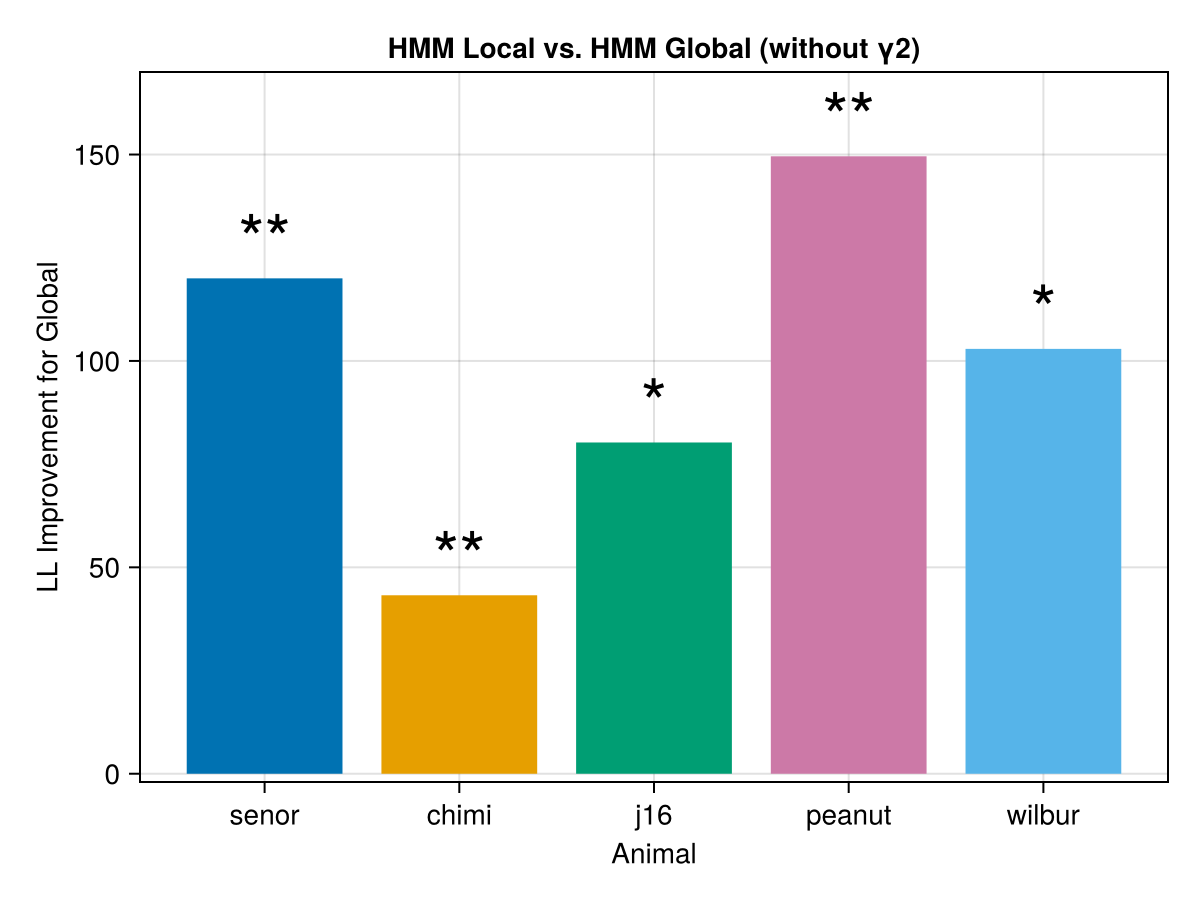

In [294]:
f = Figure()
ax = Axis(f[1,1], xlabel="Animal", ylabel="LL Improvement for Global", xticks=(1:5, animals), title="HMM Local vs. HMM Global (without γ2)")
colors = Makie.wong_colors()[1:5]
barvals = df.sum
bars = barplot!(1:5, barvals, color=colors)

for i in 1:5
    p = df.p[i]
    star = p < 0.001 ? "***" : p < 0.01 ? "**" : p < 0.05 ? "*" : p < 0.1 ? "+" : ""
    if !isempty(star)
        # Place the significance stars a bit above the bar
        text!(ax, 
            string(star), 
            position = (i, barvals[i]),
            align = (:center, :bottom), 
            color = :black, 
            fontsize = 34 # Make the stars larger
        )
    end
end
ylims!(-2.0, 170)

f

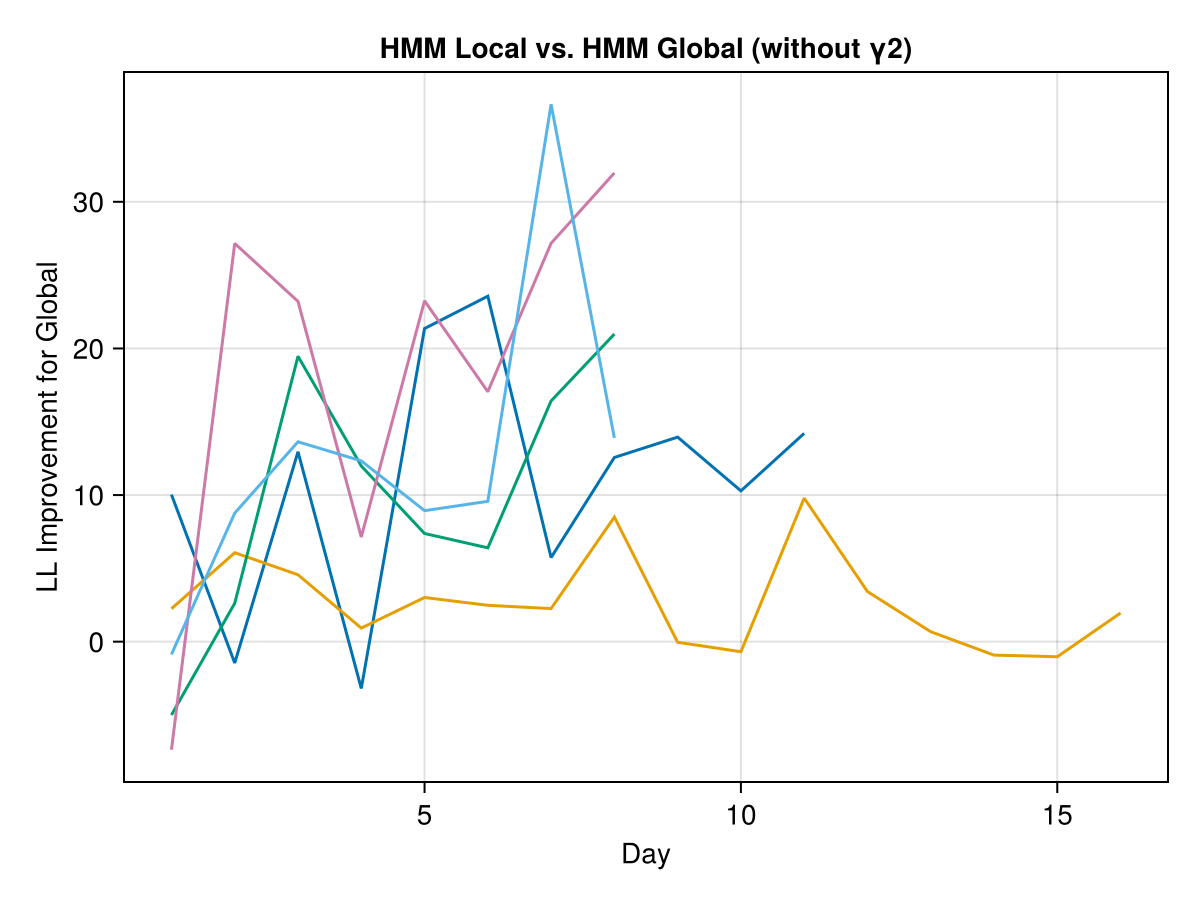

In [297]:
f = Figure()
ax = Axis(f[1,1], xlabel="Day", ylabel="LL Improvement for Global", title="HMM Local vs. HMM Global (without γ2)")
for (i, animal) in enumerate(animals)
    lines!(r1[i] .- r2[i], color=colors[i])
end
f

## Beta Bernoulli vs. old Global HMM (no γ2)

In [298]:
r1 = rs_hmm_loocv
r2 = rs_beta_loocv
loocv_means = [mean(r1[i] .- r2[i]) for i in 1:5]
loocv_sums = [sum(r1[i] .- r2[i]) for i in 1:5]
loocv_ps = [pvalue(OneSampleTTest(r1[i] .- r2[i])) for i in 1:5]
df = DataFrame(animal = animals, mu = loocv_means, p = loocv_ps, sum = loocv_sums)

Row,animal,mu,p,sum
,String,Float64,Float64,Float64
1,senor,1.75164,0.0718392,19.268
2,chimi,0.674579,0.260379,10.7933
3,j16,4.91952,0.00193193,39.3561
4,peanut,0.544528,0.685564,4.35622
5,wilbur,2.39921,0.0607924,19.1937


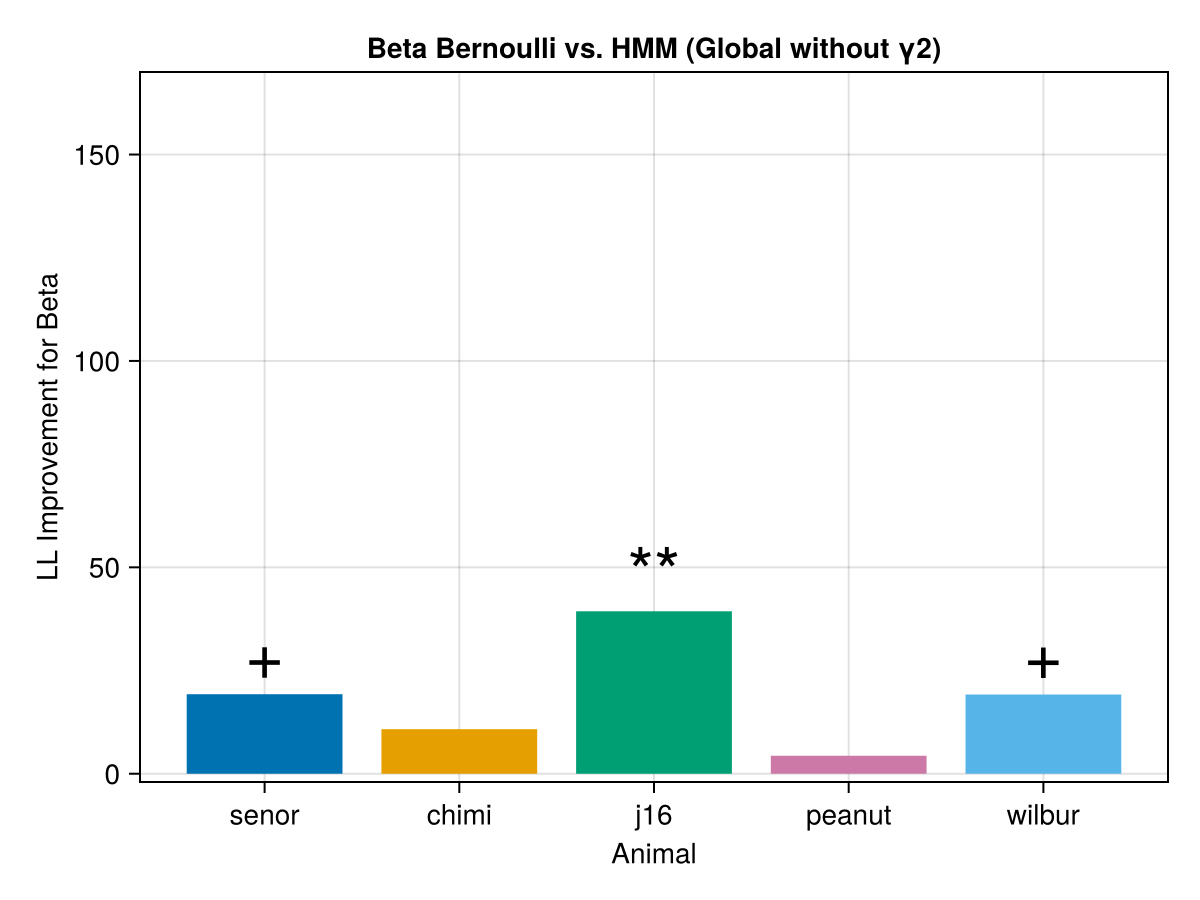

In [299]:
f = Figure()
ax = Axis(f[1,1], xlabel="Animal", ylabel="LL Improvement for Beta", xticks=(1:5, animals), title="Beta Bernoulli vs. HMM (Global without γ2)")
colors = Makie.wong_colors()[1:5]
barvals = df.sum
bars = barplot!(1:5, barvals, color=colors)

for i in 1:5
    p = df.p[i]
    star = p < 0.001 ? "***" : p < 0.01 ? "**" : p < 0.05 ? "*" : p < 0.1 ? "+" : ""
    if !isempty(star)
        # Place the significance stars a bit above the bar
        text!(ax, 
            string(star), 
            position = (i, barvals[i]),
            align = (:center, :bottom), 
            color = :black, 
            fontsize = 34 # Make the stars larger
        )
    end
end
ylims!(-2.0, 170)

f

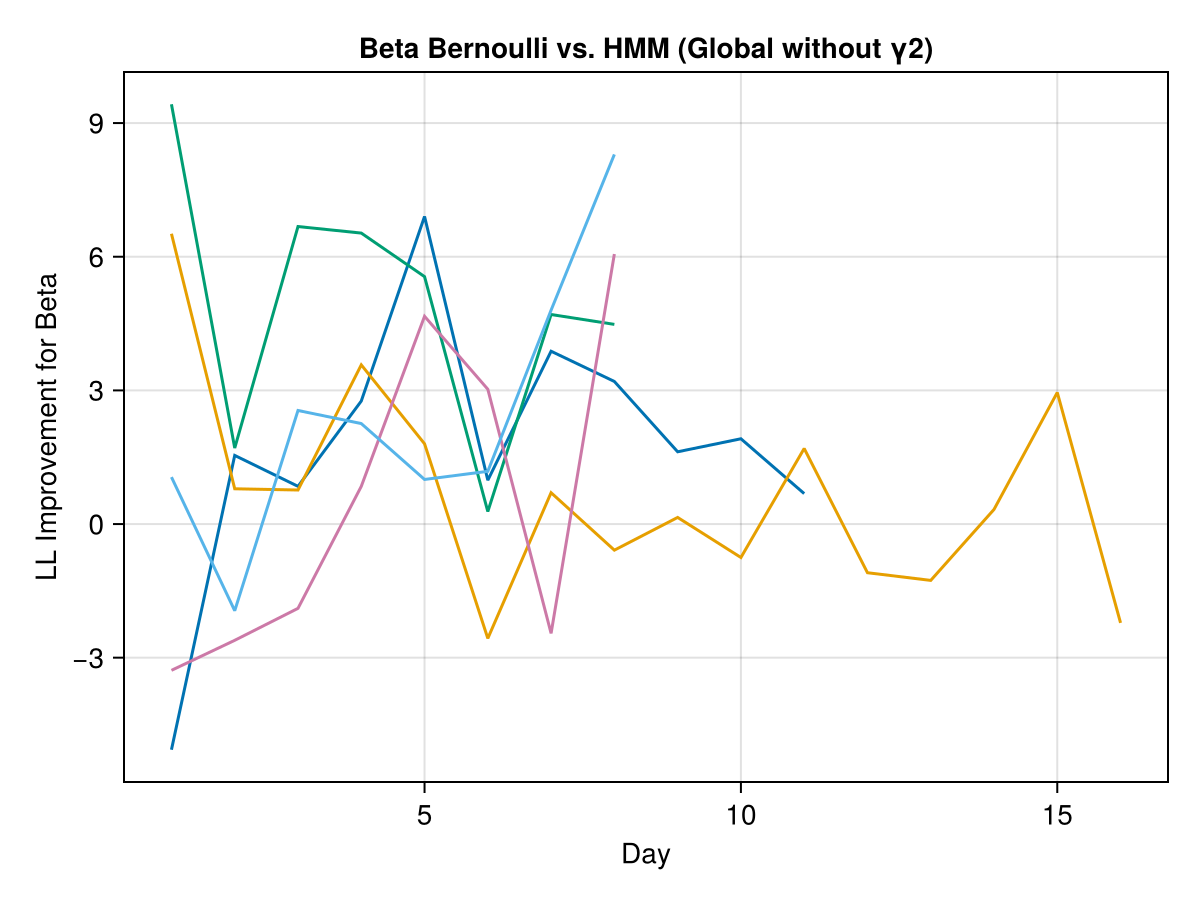

In [300]:
f = Figure()
ax = Axis(f[1,1], xlabel="Day", ylabel="LL Improvement for Beta", title="Beta Bernoulli vs. HMM (Global without γ2)")
for (i, animal) in enumerate(animals)
    lines!(r1[i] .- r2[i], color=colors[i])
end
f

## (NEW) Local vs. Global HMM (with γ2)

In [286]:
r1 = rs_hmm_g2_loocv
r2 = rs_hmm_local_g2_loocv
loocv_means = [mean(r1[i] .- r2[i]) for i in 1:5]
loocv_sums = [sum(r1[i] .- r2[i]) for i in 1:5]
loocv_ps = [pvalue(OneSampleTTest(r1[i] .- r2[i])) for i in 1:5]
df = DataFrame(animal = animals, mu = loocv_means, p = loocv_ps, sum = loocv_sums)

Row,animal,mu,p,sum
,String,Float64,Float64,Float64
1,senor,-1.45253,0.123391,-15.9778
2,chimi,0.860847,0.123941,13.7735
3,j16,-0.521374,0.491887,-4.17099
4,peanut,-2.82499,0.157115,-22.5999
5,wilbur,-1.15754,0.082817,-9.26033


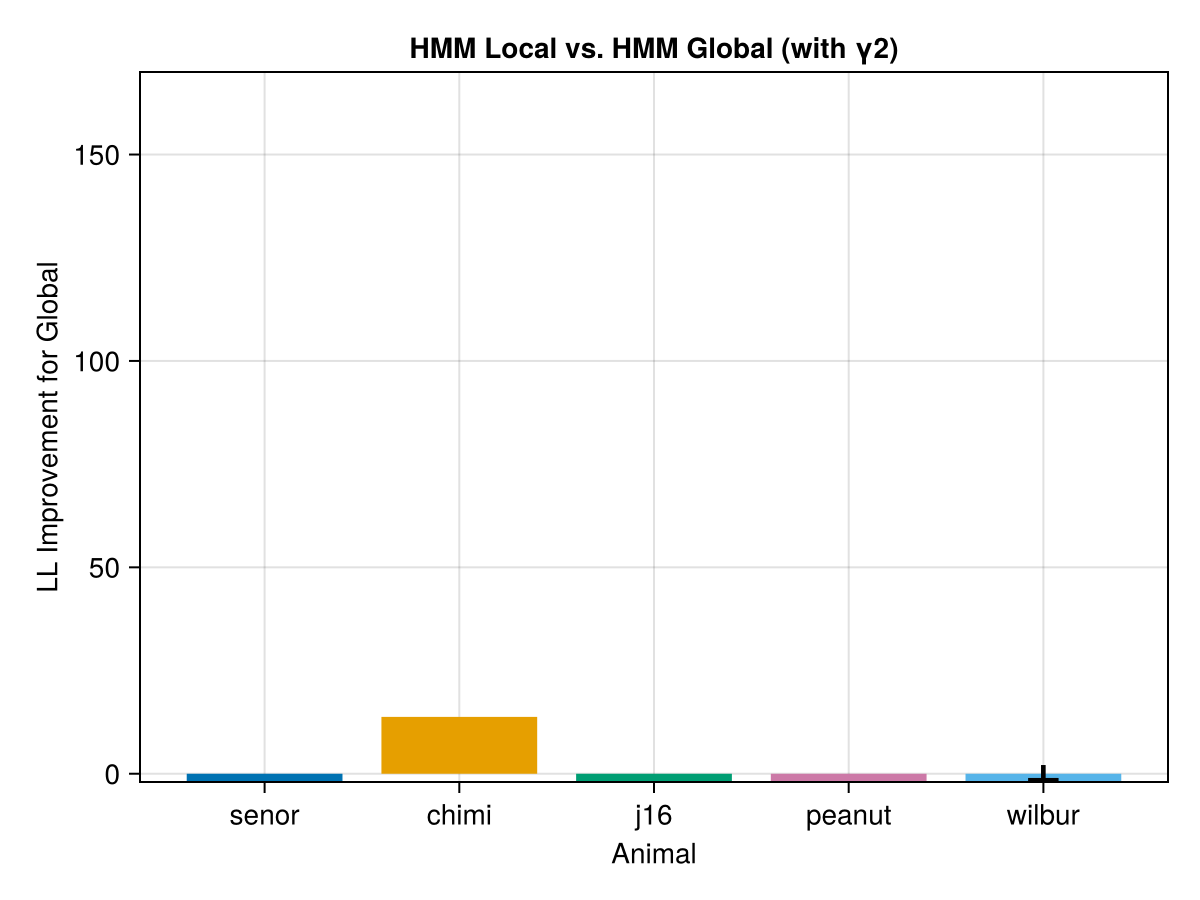

In [287]:
f = Figure()
ax = Axis(f[1,1], xlabel="Animal", ylabel="LL Improvement for Global", xticks=(1:5, animals), title="HMM Local vs. HMM Global (with γ2)")
colors = Makie.wong_colors()[1:5]
barvals = df.sum
bars = barplot!(1:5, barvals, color=colors)

for i in 1:5
    p = df.p[i]
    star = p < 0.001 ? "***" : p < 0.01 ? "**" : p < 0.05 ? "*" : p < 0.1 ? "+" : ""
    if !isempty(star)
        # Place the significance stars a bit above the bar
        text!(ax, 
            string(star), 
            position = (i, barvals[i]),
            align = (:center, :bottom), 
            color = :black, 
            fontsize = 34 # Make the stars larger
        )
    end
end
ylims!(-2.0, 170)

f

## Beta Bernoulli vs. new HMM

In [276]:
r1 = rs_hmm_g2_loocv
r2 = rs_beta_loocv
loocv_means = [mean(r1[i] .- r2[i]) for i in 1:5]
loocv_sums = [sum(r1[i] .- r2[i]) for i in 1:5]
loocv_ps = [pvalue(OneSampleTTest(r1[i] .- r2[i])) for i in 1:5]
df = DataFrame(animal = animals, mu = loocv_means, p = loocv_ps, sum = loocv_sums)

Row,animal,mu,p,sum
,String,Float64,Float64,Float64
1,senor,0.585467,0.5885,6.44014
2,chimi,0.380428,0.395288,6.08685
3,j16,3.3404,0.0269721,26.7232
4,peanut,0.0325193,0.98128,0.260154
5,wilbur,0.887552,0.471256,7.10042


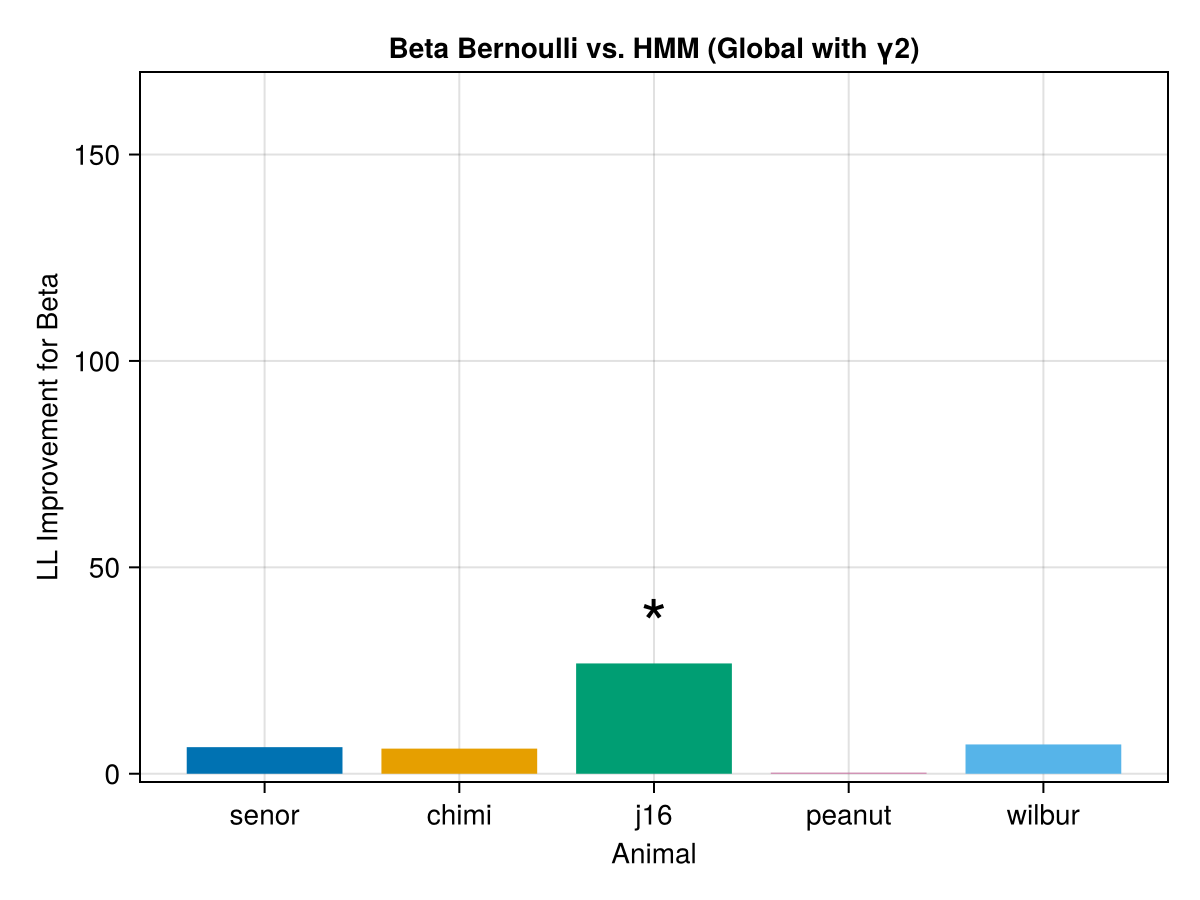

In [277]:
f = Figure()
ax = Axis(f[1,1], xlabel="Animal", ylabel="LL Improvement for Beta", xticks=(1:5, animals), title="Beta Bernoulli vs. HMM (Global with γ2)")
colors = Makie.wong_colors()[1:5]
barvals = df.sum
bars = barplot!(1:5, barvals, color=colors)

for i in 1:5
    p = df.p[i]
    star = p < 0.001 ? "***" : p < 0.01 ? "**" : p < 0.05 ? "*" : p < 0.1 ? "+" : ""
    if !isempty(star)
        # Place the significance stars a bit above the bar
        text!(ax, 
            string(star), 
            position = (i, barvals[i]),
            align = (:center, :bottom), 
            color = :black, 
            fontsize = 34 # Make the stars larger
        )
    end
end
ylims!(-2.0, 170)

f